# Property SHAP Analysis

Analyzes feature importance using SHAP values for the property pipeline. Compares CORE vs WITHRENT variants, identifies top features, and examines feature-family contributions with bootstrap confidence intervals.


## Setup

In [4]:
# Setup
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Paths
TABLES = Path("../../reports/property/tables")
FIGS = Path("../../reports/property/figures")
FIGS.mkdir(parents=True, exist_ok=True)

RUN_TAG = "PROP_v1"

# Variants to analyse 
VARIANTS = ["CORE", "WITHRENT"]

# Tasks and targets (include both 1-month and 3-month)
TASKS = [
    ('reg', 'y_ret_1m_fwd'),
    ('reg', 'y_ret_3m_fwd'),
    ('cls', 'y_up_1m'),
    ('cls', 'y_up_3m'),
]

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.style.use('seaborn-v0_8-whitegrid')

print(f"SHAP Analysis for Property Pipeline — {RUN_TAG}")
print(f"Variants: {', '.join(VARIANTS)}")
print(f"Tasks: {len(TASKS)} (regression + classification)")


SHAP Analysis for Property Pipeline — PROP_v1
Variants: CORE, WITHRENT
Tasks: 4 (regression + classification)


In [6]:
# Feature family mapper (property-specific)

def feature_family(name: str) -> str:
    """Map feature name to family (property-specific)."""
    n = name.lower()
    # Price dynamics (momentum, volatility, returns, liquidity)
    if n.startswith(('mom_', 'ret_', 'vol_', 'drawdown', 'liquidity', 'sharpe')):
        return 'price_dynamics'
    # Static context (amenities, transport, deprivation, broadband)
    if n.startswith(('fastfood', 'supermkt', 'stops_', 'imd_', 'airbnb', 'gigabit')):
        return 'static_context'
    # Time-varying context (rent indices, HPI, national trends)
    if n.startswith(('iphrp', 'hpi_')) or ('_yoy' in n and 'rent' not in n):
        return 'time_varying_context'
    # Rent features (WITHRENT only: rent growth, price-to-rent, rent gaps)
    if 'rent' in n and ('yoy' in n or 'gap' in n or 'ptr' in n or 'price_to_rent' in n):
        return 'rent_features'
    return 'other'

# Test the mapper
test_features = ['mom_3m', 'ret_1m', 'fastfood_per_1k_hh_z', 'iphrp_yoy_z_l1',
                 'rent_yoy_l1', 'price_to_rent', 'imd_score_mean_z']
for f in test_features:
    print(f"{f:25s} → {feature_family(f)}")

mom_3m                    → price_dynamics
ret_1m                    → price_dynamics
fastfood_per_1k_hh_z      → static_context
iphrp_yoy_z_l1            → time_varying_context
rent_yoy_l1               → rent_features
price_to_rent             → rent_features
imd_score_mean_z          → static_context


In [8]:
# Load & combine SHAP files across folds (per variant)

def load_shap_tables(variant: str, task: str, target: str):
    """Load SHAP files for a specific variant, task, and target."""
    # Pattern: shap_{RUN_TAG}_{variant}_{task}_{target}_{fold}.parquet
    pattern = f"shap_{RUN_TAG}_{variant}_{task}_{target}_*.parquet"
    shap_files = list(TABLES.glob(pattern))

    if not shap_files:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    # Load and combine importance files
    imp_dfs = []
    for f in shap_files:
        df = pd.read_parquet(f)
        # Extract fold from filename (last part after last underscore)
        fold_name = f.stem.split('_')[-1]
        df['fold'] = fold_name
        # Ensure the right columns
        if 'abs_shap_mean' not in df.columns and 'mean_abs_shap' in df.columns:
            df = df.rename(columns={'mean_abs_shap': 'abs_shap_mean'})
        imp_dfs.append(df)

    if not imp_dfs:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    imp_df = pd.concat(imp_dfs, ignore_index=True)

    # Create families from importance (aggregate by family and fold)
    if 'feature' in imp_df.columns:
        imp_df['family'] = imp_df['feature'].apply(feature_family)
        fam_df = (imp_df.groupby(['family', 'fold'], as_index=False)
                  .agg(mean_abs_shap=('abs_shap_mean', 'mean')))
    else:
        fam_df = pd.DataFrame()

    # load row-level SHAP files if they exist
    pattern_rows = f"shap_rows_{RUN_TAG}_{variant}_{task}_{target}_*.parquet"
    row_files = list(TABLES.glob(pattern_rows))
    if row_files:
        rec_dfs = []
        for f in row_files:
            df = pd.read_parquet(f)
            # Extract SHAP columns 
            shap_cols = [c for c in df.columns if c.startswith('shap__')]
            if shap_cols:
                # Reshape to long format: feature, mean_shap, mean_val
                for col in shap_cols:
                    feat_name = col.replace('shap__', '')
                    if feat_name in df.columns:  # Original feature exists
                        rec_dfs.append(pd.DataFrame({
                            'feature': [feat_name] * len(df),
                            'mean_shap': df[col].values,
                            'mean_val': df[feat_name].values,
                            'fold': [f.stem.split('_')[-1] for _ in range(len(df))]
                        }))
        rec_df = pd.concat(rec_dfs, ignore_index=True) if rec_dfs else pd.DataFrame()
    else:
        rec_df = pd.DataFrame()

    return imp_df, fam_df, rec_df

# Load all SHAP data
all_sets = {}

for variant in VARIANTS:
    all_sets[variant] = {}
    for task, target in TASKS:
        key = f"{task}_{target}"
        imp, fam, rec = load_shap_tables(variant, task, target)
        all_sets[variant][key] = {"imp": imp, "fam": fam, "rec": rec}
        if not imp.empty:
            print(f"{variant} {key}: {len(imp)} rows (importance), {len(fam)} rows (families), {len(rec)} rows (recipe)")
        else:
            print(f"{variant} {key}: No SHAP files found (run NB5 first)")

loaded_count = sum(1 for v in all_sets.values() for k in v.keys() if not v[k]['imp'].empty)
print(f"\nLoaded SHAP data for {loaded_count} variant-task combinations")


CORE reg_y_ret_1m_fwd: 102 rows (importance), 15 rows (families), 20400 rows (recipe)
CORE reg_y_ret_3m_fwd: 102 rows (importance), 15 rows (families), 20400 rows (recipe)
CORE cls_y_up_1m: 102 rows (importance), 15 rows (families), 20400 rows (recipe)
CORE cls_y_up_3m: 102 rows (importance), 15 rows (families), 20400 rows (recipe)
WITHRENT reg_y_ret_1m_fwd: 111 rows (importance), 15 rows (families), 22200 rows (recipe)
WITHRENT reg_y_ret_3m_fwd: 111 rows (importance), 15 rows (families), 22200 rows (recipe)
WITHRENT cls_y_up_1m: 111 rows (importance), 15 rows (families), 22200 rows (recipe)
WITHRENT cls_y_up_3m: 111 rows (importance), 15 rows (families), 22200 rows (recipe)

Loaded SHAP data for 8 variant-task combinations



 Top-15 Features by mean |SHAP| — CORE reg y_ret_1m_fwd 


,feature,abs_shap_mean
13,log_ptr,0.039106
21,rent_gap,0.026393
9,iphrp_england,0.020825
7,imd_score_mean,0.014832
22,rent_index,0.006580
17,n_sales,0.006028
14,median_rent,0.005912
12,iphrp_yoy_z_l1,0.005436
6,gigabit_pct,0.004305
18,n_sales_3m,0.004268


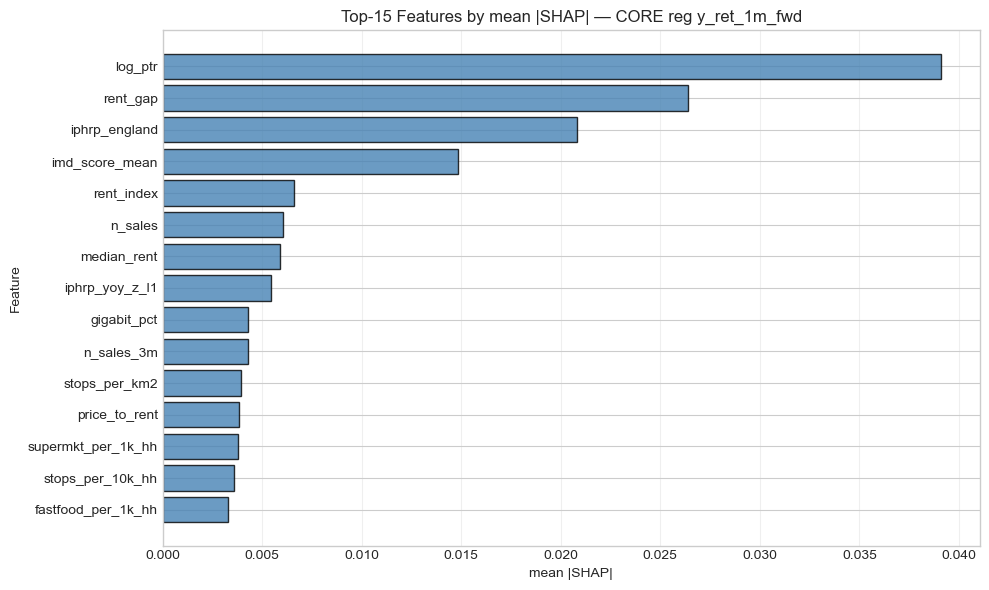


 Top-15 Features by mean |SHAP| — CORE reg y_ret_3m_fwd 


,feature,abs_shap_mean
13,log_ptr,0.044665
21,rent_gap,0.026653
9,iphrp_england,0.017017
7,imd_score_mean,0.014271
11,iphrp_yoy,0.008175
22,rent_index,0.007135
14,median_rent,0.005735
17,n_sales,0.004629
6,gigabit_pct,0.004240
30,supermkt_per_1k_hh,0.004229


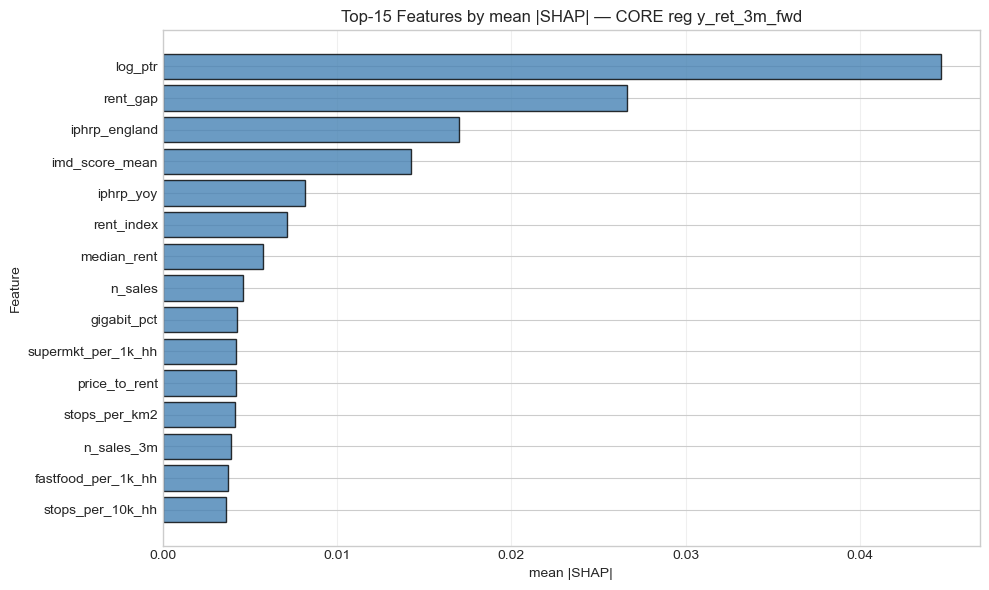


 Top-15 Features by mean |SHAP| — CORE cls y_up_1m 


,feature,abs_shap_mean
13,log_ptr,0.888121
9,iphrp_england,0.719797
21,rent_gap,0.621294
7,imd_score_mean,0.318211
12,iphrp_yoy_z_l1,0.291648
11,iphrp_yoy,0.193082
17,n_sales,0.184527
22,rent_index,0.176319
10,iphrp_england_z,0.133339
18,n_sales_3m,0.131035


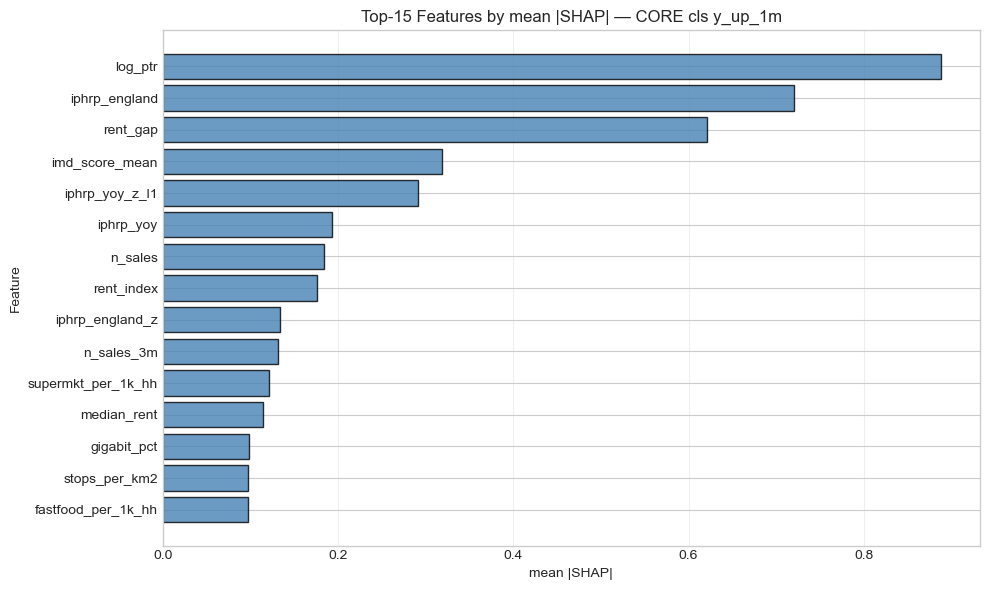


 Top-15 Features by mean |SHAP| — CORE cls y_up_3m 


,feature,abs_shap_mean
13,log_ptr,0.986404
9,iphrp_england,0.717932
21,rent_gap,0.675245
11,iphrp_yoy,0.480234
12,iphrp_yoy_z_l1,0.459001
7,imd_score_mean,0.332138
22,rent_index,0.178599
17,n_sales,0.146542
18,n_sales_3m,0.124362
14,median_rent,0.118361


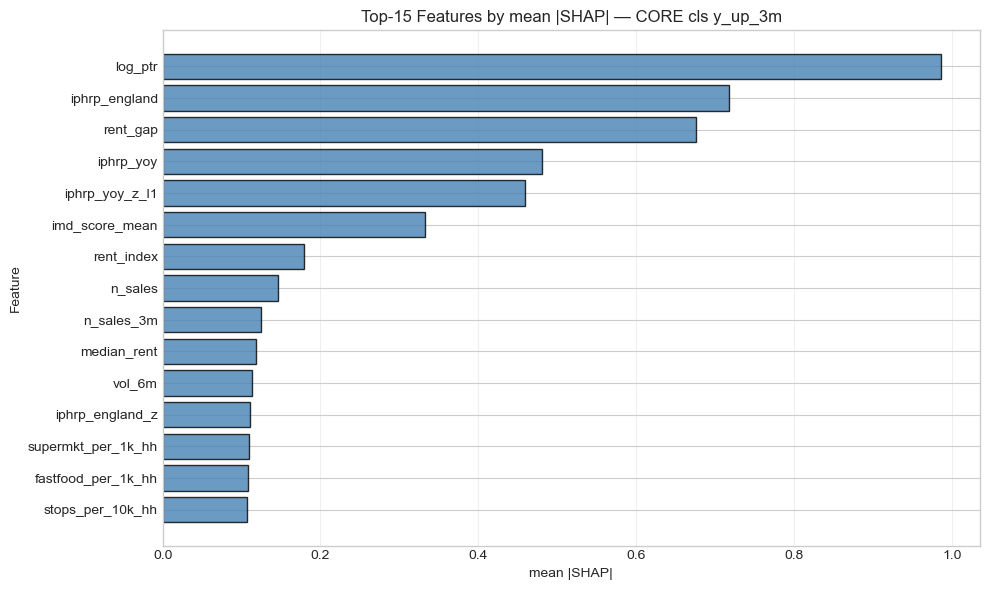


 Top-15 Features by mean |SHAP| — WITHRENT reg y_ret_1m_fwd 


,feature,abs_shap_mean
22,rent_gap,0.037395
10,iphrp_england,0.022657
8,imd_score_mean,0.021111
14,log_ptr,0.020266
15,median_rent,0.007323
6,gigabit_pct,0.006920
31,stops_per_km2,0.006549
33,supermkt_per_1k_hh,0.005748
29,stops_per_10k_hh,0.005340
23,rent_index,0.005271


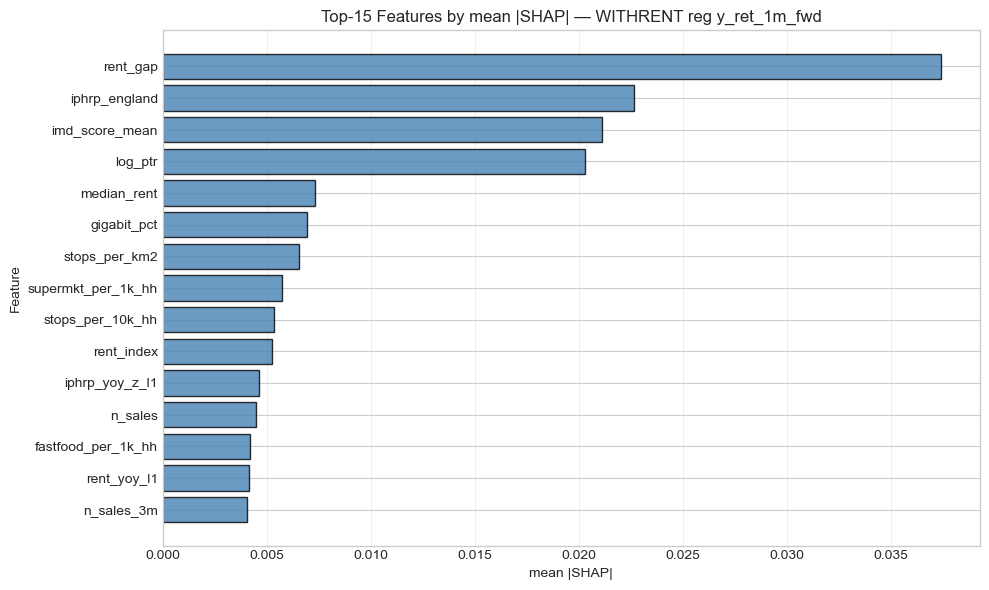


 Top-15 Features by mean |SHAP| — WITHRENT reg y_ret_3m_fwd 


,feature,abs_shap_mean
22,rent_gap,0.037952
10,iphrp_england,0.022227
8,imd_score_mean,0.019915
14,log_ptr,0.018861
25,rent_yoy_l1,0.011386
12,iphrp_yoy,0.007231
6,gigabit_pct,0.006857
15,median_rent,0.006616
23,rent_index,0.006309
31,stops_per_km2,0.005886


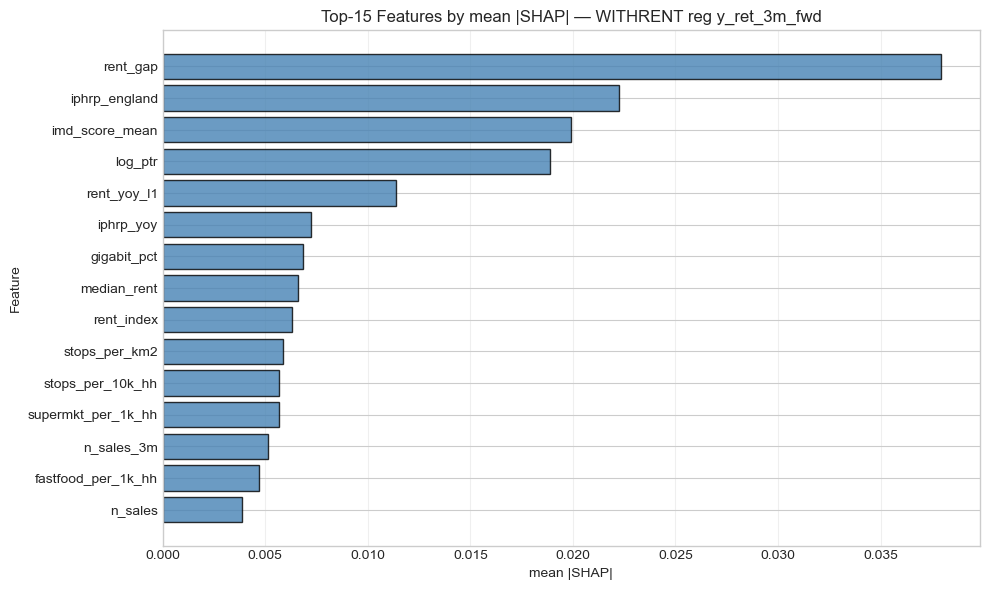


 Top-15 Features by mean |SHAP| — WITHRENT cls y_up_1m 


,feature,abs_shap_mean
22,rent_gap,0.965217
10,iphrp_england,0.832572
8,imd_score_mean,0.536747
14,log_ptr,0.514033
25,rent_yoy_l1,0.372571
13,iphrp_yoy_z_l1,0.300631
6,gigabit_pct,0.198956
33,supermkt_per_1k_hh,0.192158
29,stops_per_10k_hh,0.176790
31,stops_per_km2,0.175771


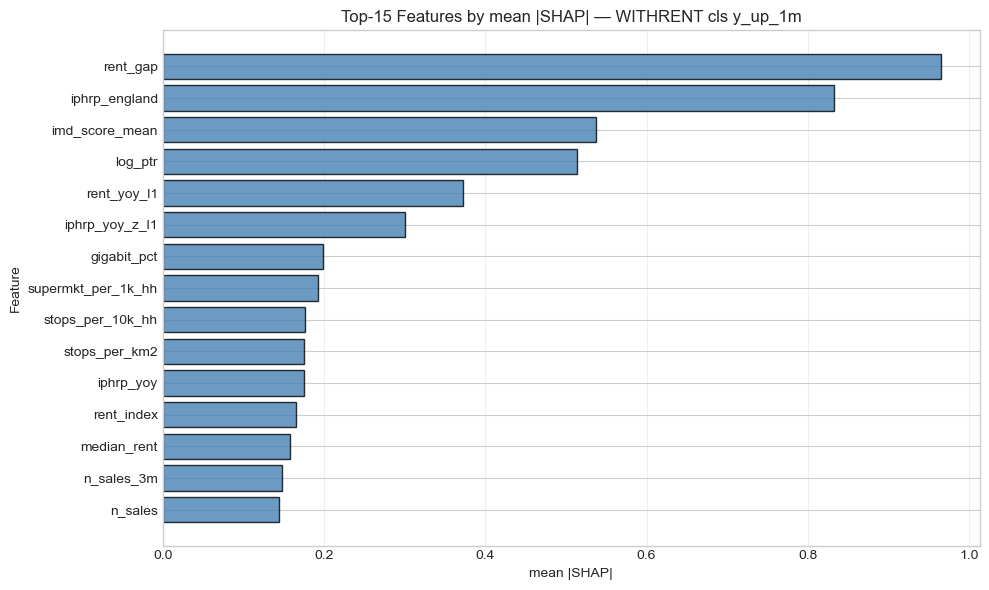


 Top-15 Features by mean |SHAP| — WITHRENT cls y_up_3m 


,feature,abs_shap_mean
22,rent_gap,1.128036
10,iphrp_england,0.887380
12,iphrp_yoy,0.640187
8,imd_score_mean,0.632059
14,log_ptr,0.520545
25,rent_yoy_l1,0.461891
13,iphrp_yoy_z_l1,0.433350
6,gigabit_pct,0.201875
33,supermkt_per_1k_hh,0.196724
31,stops_per_km2,0.190120


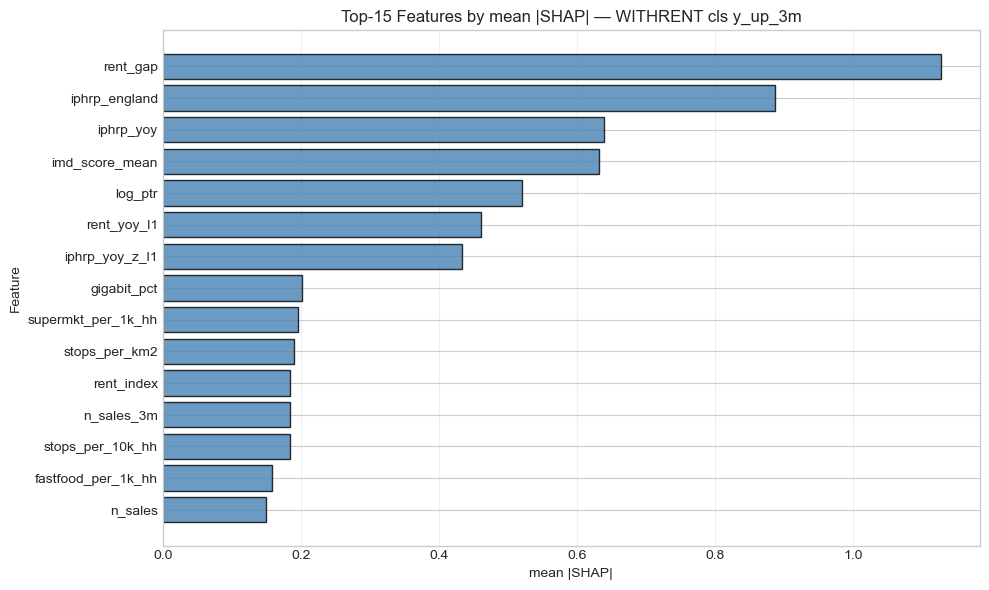

In [10]:
# Aggregate feature importances across folds & plot top-k

def agg_feature_importance(imp_df: pd.DataFrame, top_k=15):
    """Average mean_abs_shap across folds."""
    if imp_df.empty or 'feature' not in imp_df.columns:
        return pd.DataFrame()
    agg = (imp_df.groupby("feature", as_index=False)["abs_shap_mean"].mean()
           .sort_values("abs_shap_mean", ascending=False))
    return agg.head(top_k)

for variant in VARIANTS:
    for task, target in TASKS:
        key = f"{task}_{target}"
        if key not in all_sets[variant]:
            continue

        d = all_sets[variant][key]
        if d["imp"].empty:
            continue

        agg = agg_feature_importance(d["imp"], top_k=15)
        if agg.empty:
            continue

        print(f"\n Top-15 Features by mean |SHAP| — {variant} {task} {target} ")
        display(agg.head(15))

        # Plot 
        plt.figure(figsize=(10, 6))
        plt.barh(agg["feature"][::-1], agg["abs_shap_mean"][::-1],
                color='steelblue', edgecolor='black', alpha=0.8)
        plt.title(f"Top-15 Features by mean |SHAP| — {variant} {task} {target}")
        plt.xlabel("mean |SHAP|")
        plt.ylabel("Feature")
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(FIGS / f"shap_top15_{variant}_{task}_{target}.png", dpi=150, bbox_inches='tight')
        plt.show()

\ Feature Families with 95% CI — CORE reg y_ret_1m_fwd 
(Bootstrap CIs resampled across folds)


,family,mean_abs_shap,ci_lower,ci_upper
2,rent_features,0.015115,0.014099,0.016766
4,time_varying_context,0.008050,0.003102,0.011894
0,other,0.007743,0.007399,0.007970
3,static_context,0.002995,0.002810,0.003261
1,price_dynamics,0.001955,0.001944,0.001969



Statistical Significance Check:
   rent_features > time_varying_context (non-overlapping CIs)
   rent_features > other (non-overlapping CIs)


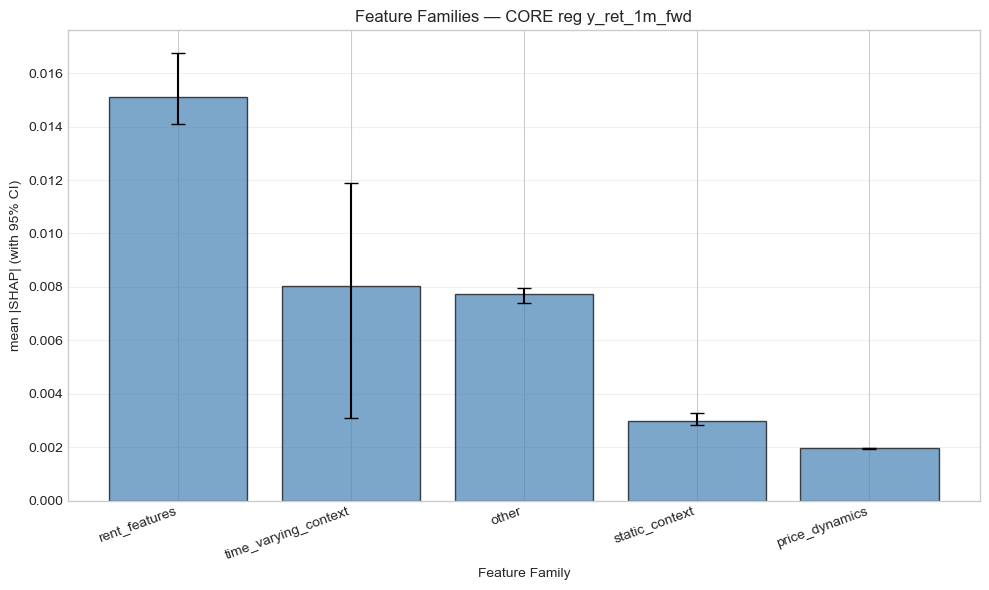

\ Feature Families with 95% CI — CORE reg y_ret_3m_fwd 
(Bootstrap CIs resampled across folds)


,family,mean_abs_shap,ci_lower,ci_upper
2,rent_features,0.015431,0.014601,0.016989
0,other,0.008268,0.007651,0.008665
4,time_varying_context,0.007642,0.004589,0.013635
3,static_context,0.003060,0.002911,0.003341
1,price_dynamics,0.002194,0.002140,0.002273



Statistical Significance Check:
   rent_features > other (non-overlapping CIs)
   rent_features > time_varying_context (non-overlapping CIs)


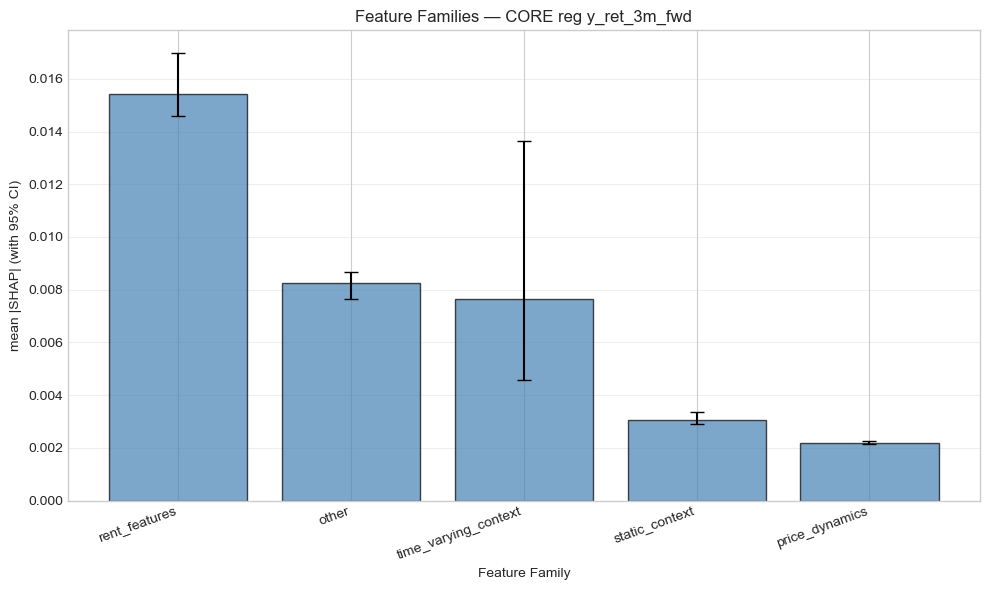

\ Feature Families with 95% CI — CORE cls y_up_1m 
(Bootstrap CIs resampled across folds)


,family,mean_abs_shap,ci_lower,ci_upper
2,rent_features,0.355296,0.286895,0.406301
4,time_varying_context,0.334467,0.138693,0.599327
0,other,0.187082,0.173059,0.212329
3,static_context,0.073488,0.071792,0.075123
1,price_dynamics,0.066839,0.062511,0.072544



Statistical Significance Check:
   rent_features vs time_varying_context (overlapping CIs - not significantly different)
   rent_features > other (non-overlapping CIs)


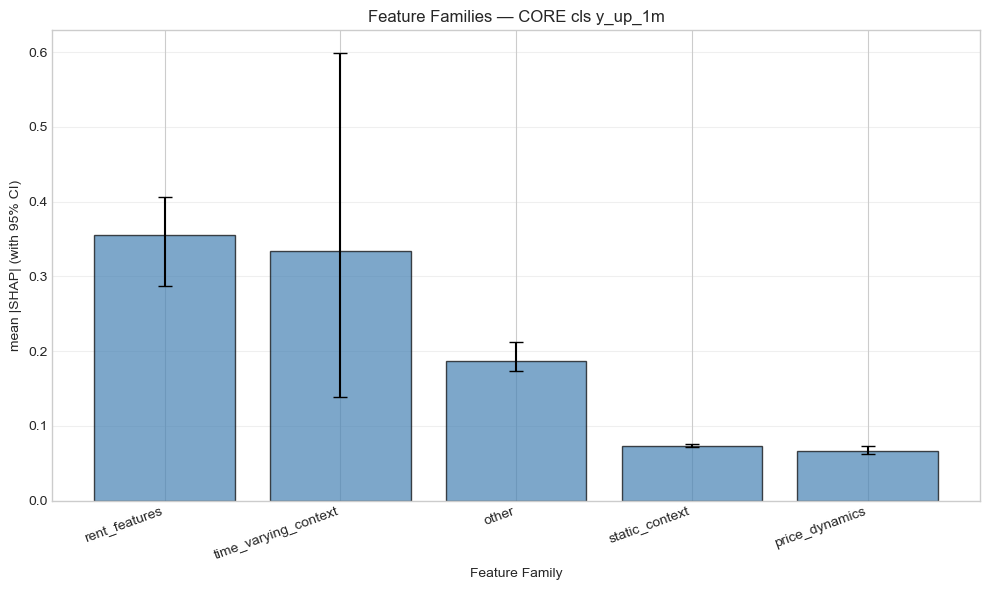

\ Feature Families with 95% CI — CORE cls y_up_3m 
(Bootstrap CIs resampled across folds)


,family,mean_abs_shap,ci_lower,ci_upper
4,time_varying_context,0.441814,0.185432,0.780347
2,rent_features,0.384681,0.336137,0.425651
0,other,0.194687,0.188753,0.200141
1,price_dynamics,0.081634,0.076431,0.084639
3,static_context,0.074998,0.068670,0.079031



Statistical Significance Check:
   time_varying_context vs rent_features (overlapping CIs - not significantly different)
   time_varying_context vs other (overlapping CIs - not significantly different)


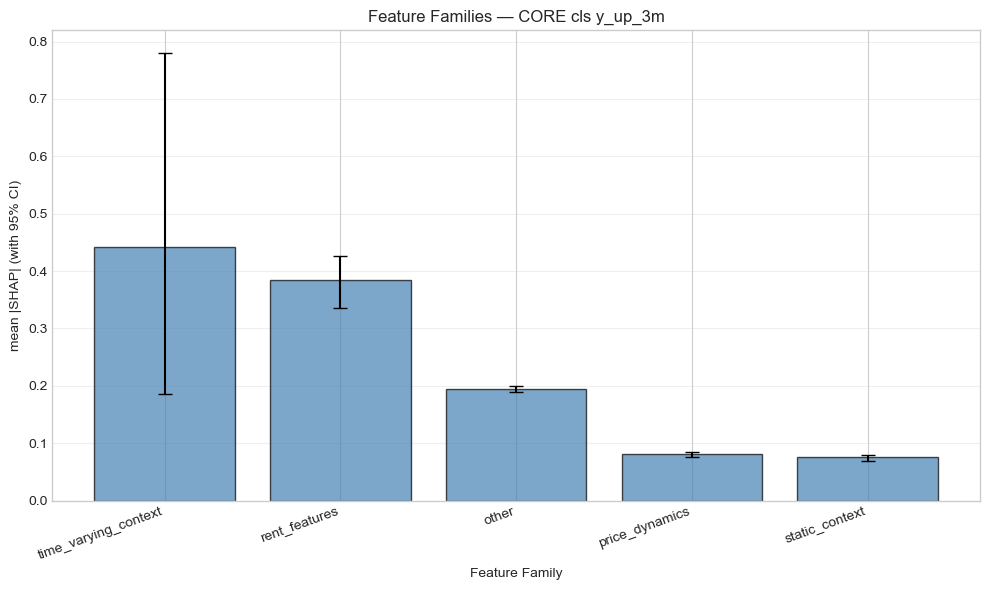

\ Feature Families with 95% CI — WITHRENT reg y_ret_1m_fwd 
(Bootstrap CIs resampled across folds)


,family,mean_abs_shap,ci_lower,ci_upper
2,rent_features,0.011313,0.007953,0.013748
4,time_varying_context,0.007176,0.002085,0.011531
0,other,0.005199,0.004836,0.005578
3,static_context,0.004354,0.004132,0.004632
1,price_dynamics,0.002226,0.002017,0.002525



Statistical Significance Check:
   rent_features vs time_varying_context (overlapping CIs - not significantly different)
   rent_features > other (non-overlapping CIs)


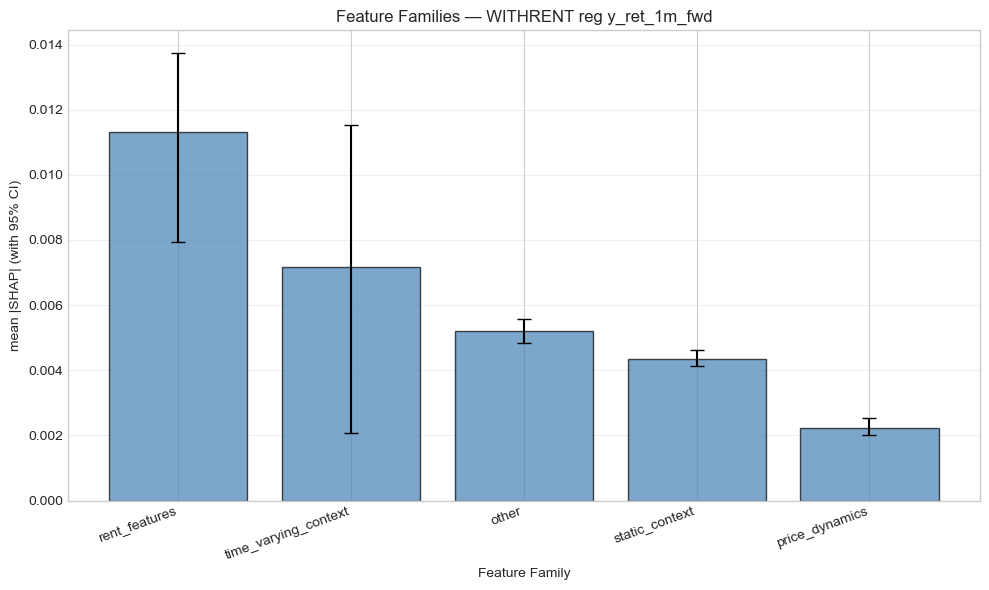

\ Feature Families with 95% CI — WITHRENT reg y_ret_3m_fwd 
(Bootstrap CIs resampled across folds)


,family,mean_abs_shap,ci_lower,ci_upper
2,rent_features,0.013093,0.007727,0.017369
4,time_varying_context,0.007189,0.003168,0.012469
0,other,0.005114,0.004705,0.005919
3,static_context,0.004222,0.003994,0.004531
1,price_dynamics,0.002215,0.002041,0.002322



Statistical Significance Check:
   rent_features vs time_varying_context (overlapping CIs - not significantly different)
   rent_features > other (non-overlapping CIs)


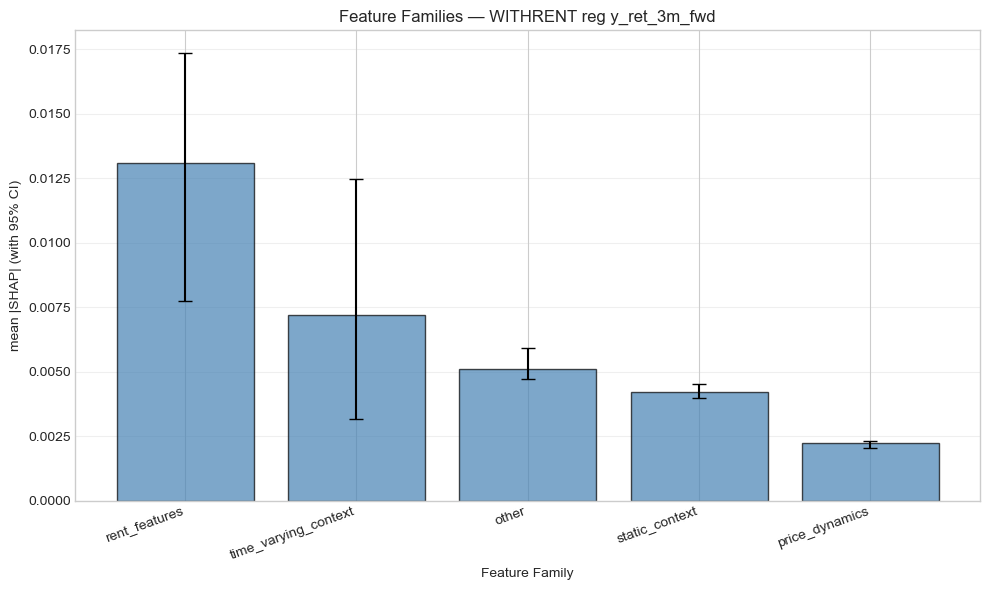

\ Feature Families with 95% CI — WITHRENT cls y_up_1m 
(Bootstrap CIs resampled across folds)


,family,mean_abs_shap,ci_lower,ci_upper
2,rent_features,0.370075,0.247968,0.460877
4,time_varying_context,0.295879,0.128876,0.505079
0,other,0.141855,0.123514,0.155034
3,static_context,0.124135,0.121109,0.128733
1,price_dynamics,0.108367,0.099039,0.126508



Statistical Significance Check:
   rent_features vs time_varying_context (overlapping CIs - not significantly different)
   rent_features > other (non-overlapping CIs)


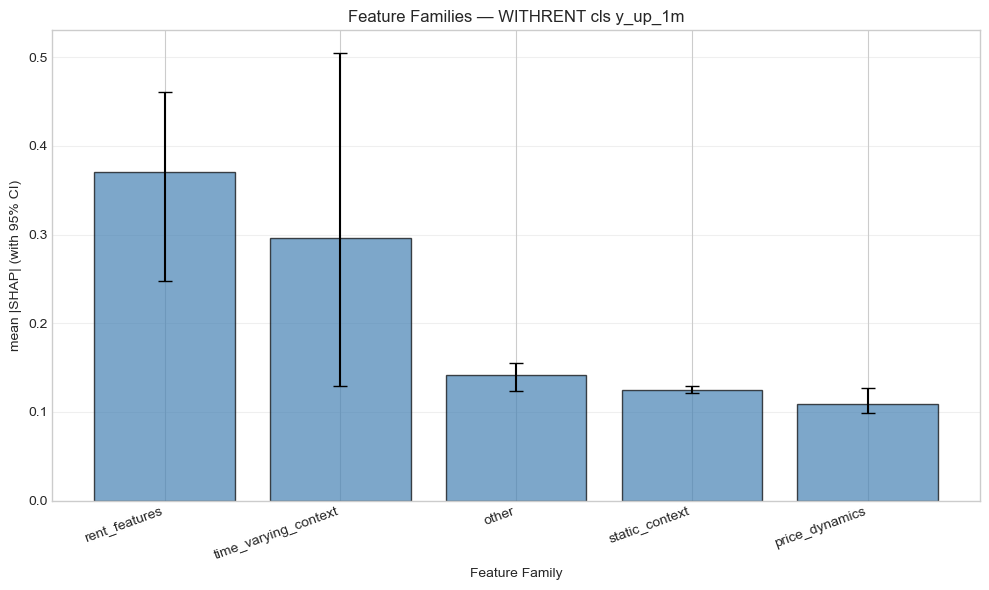

\ Feature Families with 95% CI — WITHRENT cls y_up_3m 
(Bootstrap CIs resampled across folds)


,family,mean_abs_shap,ci_lower,ci_upper
2,rent_features,0.440996,0.292218,0.575958
4,time_varying_context,0.440625,0.182193,0.780730
0,other,0.148970,0.129313,0.165517
3,static_context,0.136487,0.128491,0.142009
1,price_dynamics,0.115000,0.102036,0.127940



Statistical Significance Check:
   rent_features vs time_varying_context (overlapping CIs - not significantly different)
   rent_features > other (non-overlapping CIs)


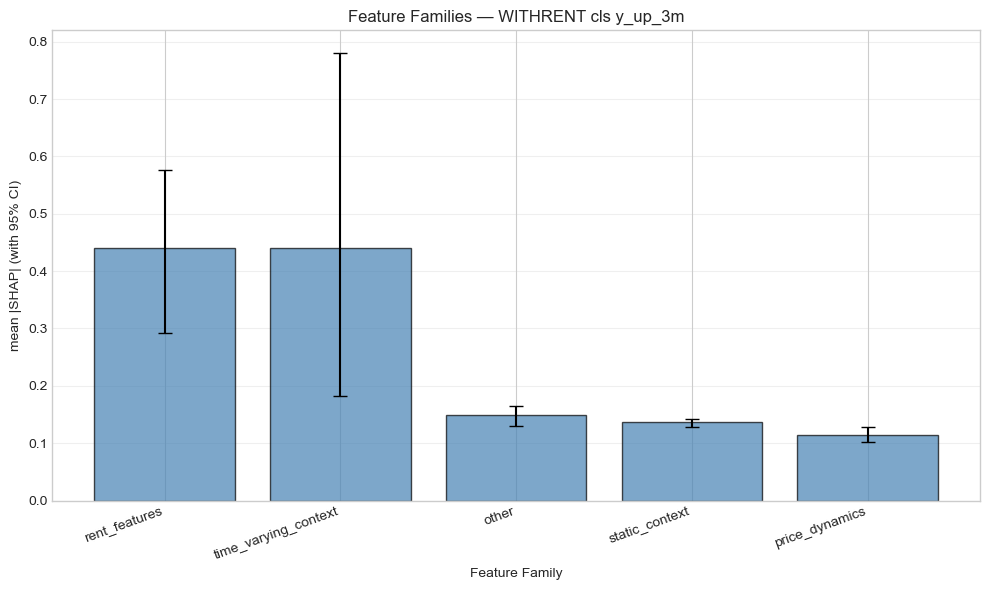

In [12]:
# Aggregate families with bootstrap confidence intervals

def agg_families_with_ci(fam_df: pd.DataFrame, n_bootstrap=1000, ci_level=0.95):
    """Aggregate families with bootstrap CIs (exact match to stocks pipeline)."""
    if fam_df.empty:
        return pd.DataFrame(columns=["family", "mean_abs_shap", "ci_lower", "ci_upper"])

    # Get fold-level data
    fold_data = fam_df.groupby(["family", "fold"], as_index=False)["mean_abs_shap"].first()

    results = []
    for family in fold_data["family"].unique():
        family_folds = fold_data[fold_data["family"] == family]["mean_abs_shap"].values

        if len(family_folds) < 2:
            mean_val = family_folds[0] if len(family_folds) == 1 else np.nan
            results.append({
                "family": family,
                "mean_abs_shap": mean_val,
                "ci_lower": mean_val,
                "ci_upper": mean_val
            })
            continue

        # Bootstrap
        np.random.seed(42)
        bootstrap_means = []
        for _ in range(n_bootstrap):
            resampled = np.random.choice(family_folds, size=len(family_folds), replace=True)
            bootstrap_means.append(np.mean(resampled))

        alpha = 1 - ci_level
        ci_lower = np.percentile(bootstrap_means, 100 * alpha / 2)
        ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))
        mean_val = np.mean(family_folds)

        results.append({
            "family": family,
            "mean_abs_shap": mean_val,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper
        })

    return pd.DataFrame(results).sort_values("mean_abs_shap", ascending=False)

# Store for comparison
fam_agg_core = {}
fam_agg_wr = {}

for variant in VARIANTS:
    for task, target in TASKS:
        key = f"{task}_{target}"
        if key not in all_sets[variant]:
            continue

        d = all_sets[variant][key]
        if d["fam"].empty:
            continue

        fam_agg = agg_families_with_ci(d["fam"], n_bootstrap=1000, ci_level=0.95)

        print(f"\ Feature Families with 95% CI — {variant} {task} {target} ")
        print("(Bootstrap CIs resampled across folds)")
        display(fam_agg)

        # Store for comparison
        if variant == "CORE":
            fam_agg_core[key] = fam_agg.copy()
        elif variant == "WITHRENT":
            fam_agg_wr[key] = fam_agg.copy()

        # Statistical significance check
        if len(fam_agg) > 1:
            print(f"\nStatistical Significance Check:")
            top_fam = fam_agg.iloc[0]
            for i in range(1, min(3, len(fam_agg))):
                comp_fam = fam_agg.iloc[i]
                if top_fam["ci_lower"] > comp_fam["ci_upper"]:
                    print(f"   {top_fam['family']} > {comp_fam['family']} (non-overlapping CIs)")
                elif comp_fam["ci_lower"] > top_fam["ci_upper"]:
                    print(f"   {comp_fam['family']} > {top_fam['family']} (non-overlapping CIs)")
                else:
                    print(f"   {top_fam['family']} vs {comp_fam['family']} (overlapping CIs - not significantly different)")

        # Plot
        if not fam_agg.empty:
            plt.figure(figsize=(10, 6))
            x_pos = np.arange(len(fam_agg))
            means = fam_agg["mean_abs_shap"].values
            errors = [means - fam_agg["ci_lower"].values, fam_agg["ci_upper"].values - means]

            plt.bar(x_pos, means, yerr=errors, capsize=5, alpha=0.7,
                   color='steelblue', edgecolor='black')
            plt.xlabel("Feature Family")
            plt.ylabel("mean |SHAP| (with 95% CI)")
            plt.title(f"Feature Families — {variant} {task} {target}")
            plt.xticks(x_pos, fam_agg["family"], rotation=20, ha="right")
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.savefig(FIGS / f"shap_families_{variant}_{task}_{target}.png", dpi=150, bbox_inches='tight')
            plt.show()


 CORE vs WITHRENT Comparison (95% Bootstrap CIs) — reg y_ret_1m_fwd 

Statistically Significant Differences:
   CORE rent_features > WITHRENT rent_features (non-overlapping CIs)
   CORE other > WITHRENT other (non-overlapping CIs)
   WITHRENT static_context > CORE static_context (non-overlapping CIs)
   WITHRENT price_dynamics > CORE price_dynamics (non-overlapping CIs)

Comparison Table:


,family,mean_abs_shap_CORE,ci_lower_CORE,ci_upper_CORE,mean_abs_shap_WITHRENT,ci_lower_WITHRENT,ci_upper_WITHRENT
2,rent_features,0.01512,0.01410,0.01677,0.01131,0.00795,0.01375
4,time_varying_context,0.00805,0.00310,0.01189,0.00718,0.00209,0.01153
0,other,0.00774,0.00740,0.00797,0.00520,0.00484,0.00558
3,static_context,0.00300,0.00281,0.00326,0.00435,0.00413,0.00463
1,price_dynamics,0.00196,0.00194,0.00197,0.00223,0.00202,0.00253


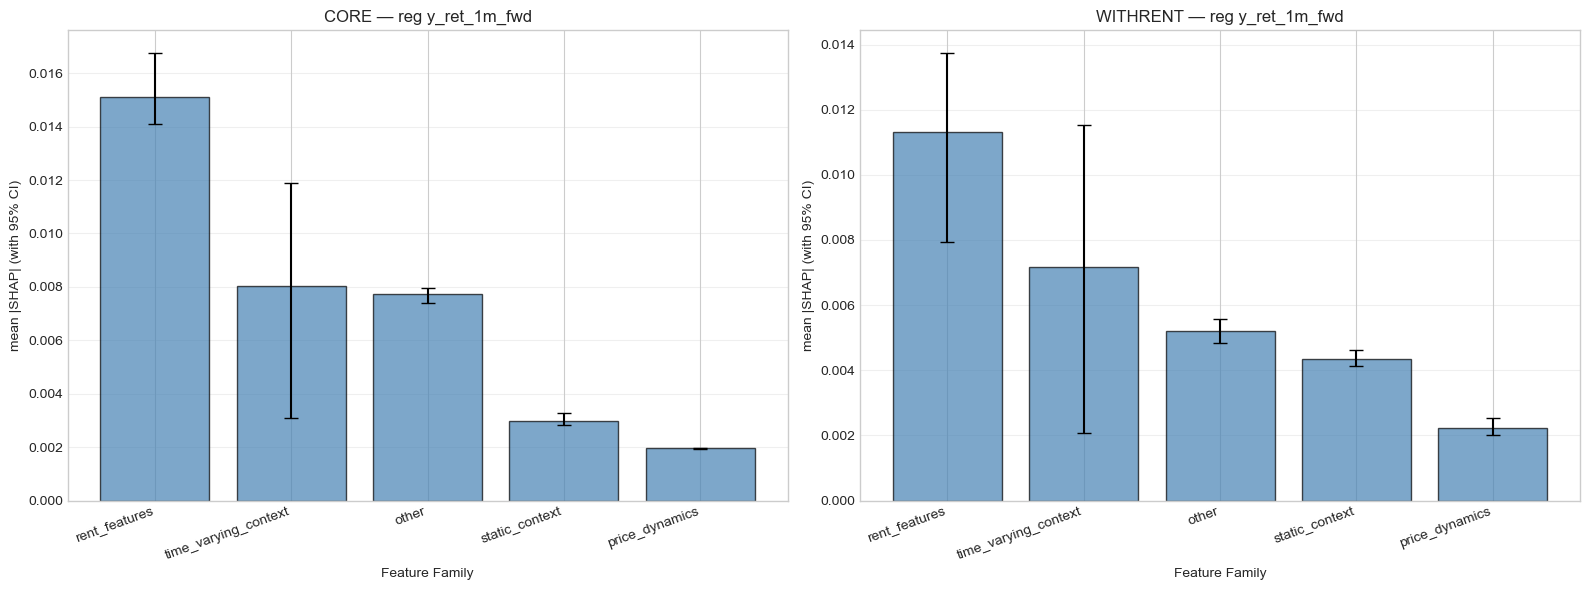


 CORE vs WITHRENT Comparison (95% Bootstrap CIs) — reg y_ret_3m_fwd 

Statistically Significant Differences:
   CORE other > WITHRENT other (non-overlapping CIs)
   WITHRENT static_context > CORE static_context (non-overlapping CIs)

Comparison Table:


,family,mean_abs_shap_CORE,ci_lower_CORE,ci_upper_CORE,mean_abs_shap_WITHRENT,ci_lower_WITHRENT,ci_upper_WITHRENT
2,rent_features,0.01543,0.01460,0.01699,0.01309,0.00773,0.01737
0,other,0.00827,0.00765,0.00866,0.00511,0.00471,0.00592
4,time_varying_context,0.00764,0.00459,0.01364,0.00719,0.00317,0.01247
3,static_context,0.00306,0.00291,0.00334,0.00422,0.00399,0.00453
1,price_dynamics,0.00219,0.00214,0.00227,0.00222,0.00204,0.00232


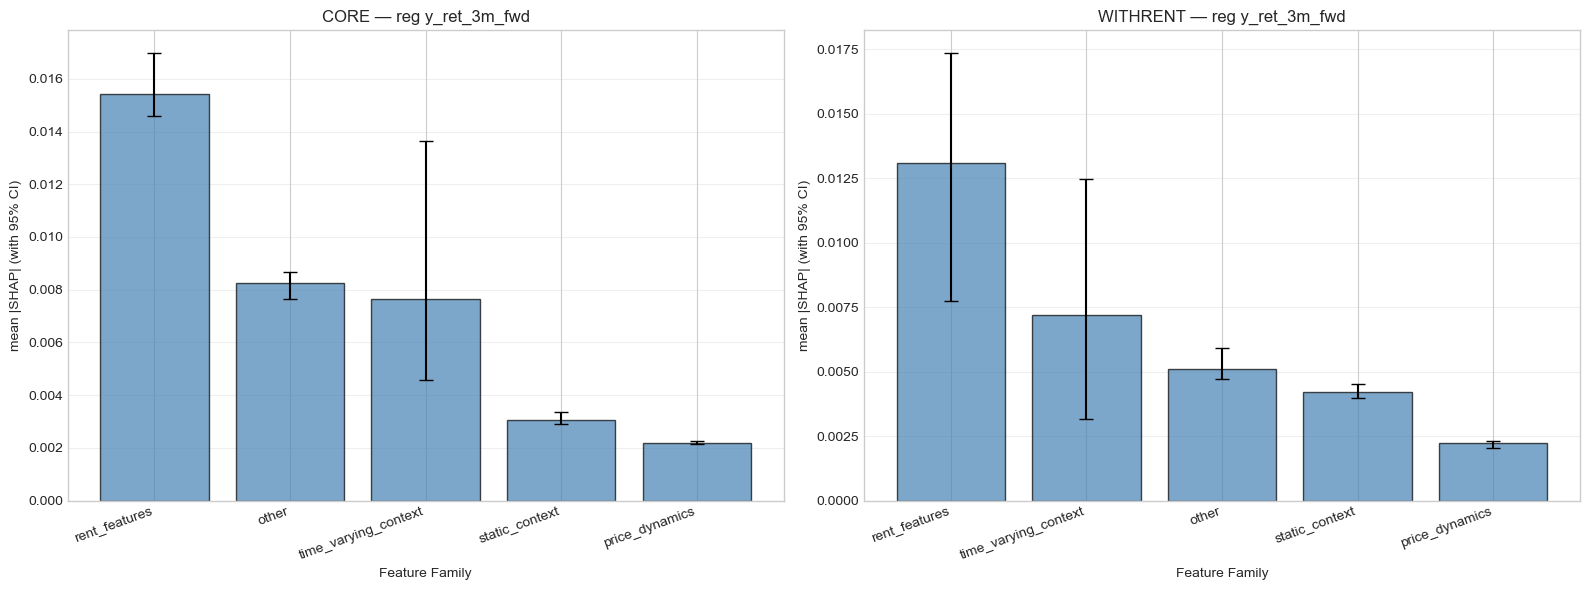


 CORE vs WITHRENT Comparison (95% Bootstrap CIs) — cls y_up_1m 

Statistically Significant Differences:
   CORE other > WITHRENT other (non-overlapping CIs)
   WITHRENT static_context > CORE static_context (non-overlapping CIs)
   WITHRENT price_dynamics > CORE price_dynamics (non-overlapping CIs)

Comparison Table:


,family,mean_abs_shap_CORE,ci_lower_CORE,ci_upper_CORE,mean_abs_shap_WITHRENT,ci_lower_WITHRENT,ci_upper_WITHRENT
2,rent_features,0.35530,0.28690,0.40630,0.37008,0.24797,0.46088
4,time_varying_context,0.33447,0.13869,0.59933,0.29588,0.12888,0.50508
0,other,0.18708,0.17306,0.21233,0.14186,0.12351,0.15503
3,static_context,0.07349,0.07179,0.07512,0.12414,0.12111,0.12873
1,price_dynamics,0.06684,0.06251,0.07254,0.10837,0.09904,0.12651


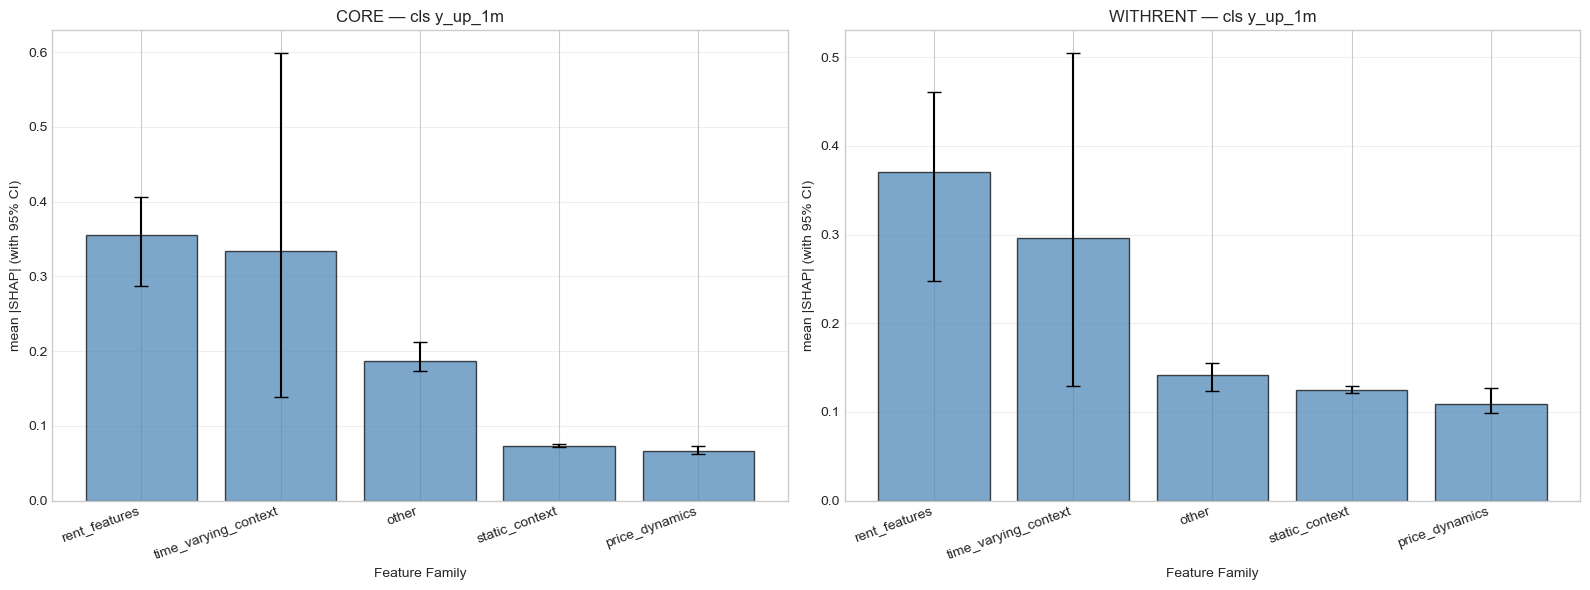


 CORE vs WITHRENT Comparison (95% Bootstrap CIs) — cls y_up_3m 

Statistically Significant Differences:
   CORE other > WITHRENT other (non-overlapping CIs)
   WITHRENT price_dynamics > CORE price_dynamics (non-overlapping CIs)
   WITHRENT static_context > CORE static_context (non-overlapping CIs)

Comparison Table:


,family,mean_abs_shap_CORE,ci_lower_CORE,ci_upper_CORE,mean_abs_shap_WITHRENT,ci_lower_WITHRENT,ci_upper_WITHRENT
4,time_varying_context,0.44181,0.18543,0.78035,0.44063,0.18219,0.78073
2,rent_features,0.38468,0.33614,0.42565,0.44100,0.29222,0.57596
0,other,0.19469,0.18875,0.20014,0.14897,0.12931,0.16552
1,price_dynamics,0.08163,0.07643,0.08464,0.11500,0.10204,0.12794
3,static_context,0.07500,0.06867,0.07903,0.13649,0.12849,0.14201


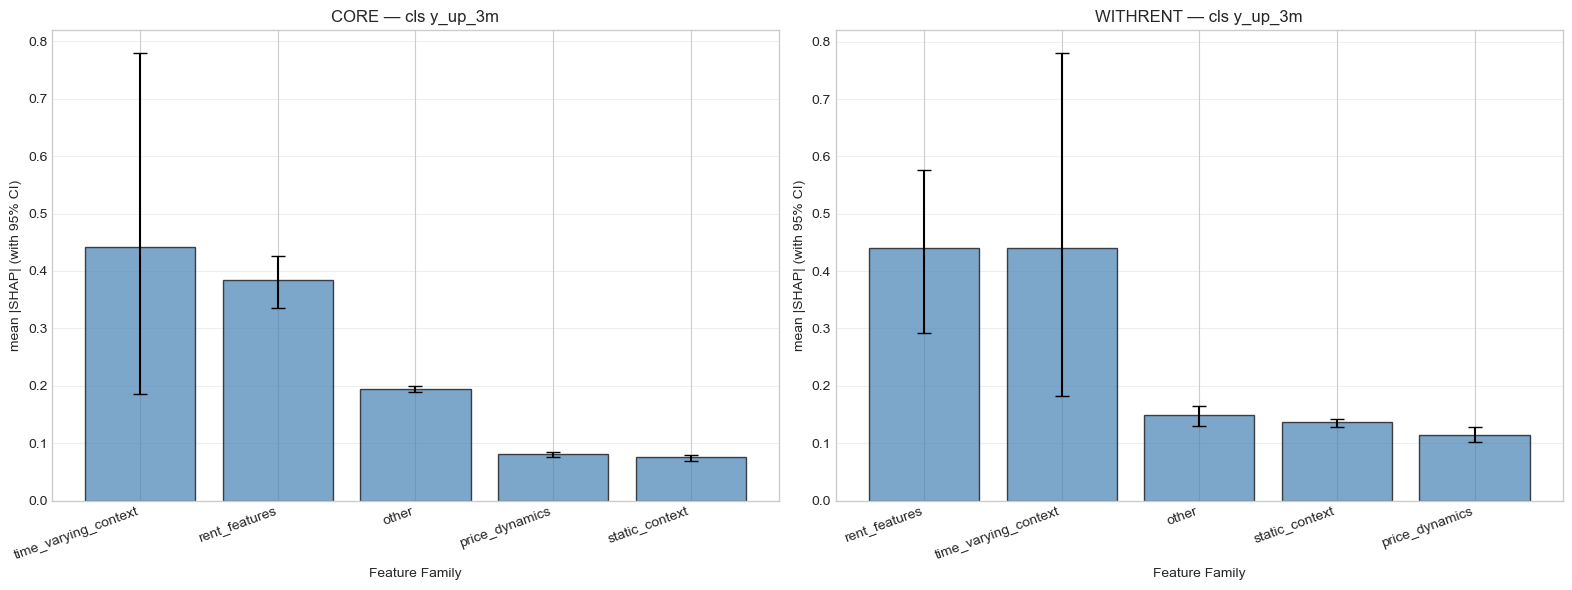

In [14]:
# CORE vs WITHRENT Comparison


for task, target in TASKS:
    key = f"{task}_{target}"

    if key not in fam_agg_core or key not in fam_agg_wr:
        continue

    core_fam = fam_agg_core[key]
    wr_fam = fam_agg_wr[key]

    comparison = core_fam.merge(wr_fam, on="family", suffixes=("_CORE", "_WITHRENT"), how="outer").fillna(0)
    comparison = comparison.sort_values("mean_abs_shap_CORE", ascending=False)

    print(f"\n{'='*70}")
    print(f" CORE vs WITHRENT Comparison (95% Bootstrap CIs) — {task} {target} ")
    print(f"{'='*70}")

    # Check for significant differences
    sig_diffs = []
    for _, row in comparison.iterrows():
        core_lower = row["ci_lower_CORE"]
        core_upper = row["ci_upper_CORE"]
        wr_lower = row["ci_lower_WITHRENT"]
        wr_upper = row["ci_upper_WITHRENT"]

        if core_lower > wr_upper:
            sig_diffs.append(f"CORE {row['family']} > WITHRENT {row['family']} (non-overlapping CIs)")
        elif wr_lower > core_upper:
            sig_diffs.append(f"WITHRENT {row['family']} > CORE {row['family']} (non-overlapping CIs)")

    if sig_diffs:
        print("\nStatistically Significant Differences:")
        for diff in sig_diffs:
            print(f"   {diff}")
    else:
        print("\nNo statistically significant differences (all CIs overlap)")

    print(f"\nComparison Table:")
    display(comparison[["family", "mean_abs_shap_CORE", "ci_lower_CORE", "ci_upper_CORE",
                       "mean_abs_shap_WITHRENT", "ci_lower_WITHRENT", "ci_upper_WITHRENT"]].round(5))

    # Side-by-side plot 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for ax, fam_data, label in [(ax1, core_fam, "CORE"), (ax2, wr_fam, "WITHRENT")]:
        x_pos = np.arange(len(fam_data))
        means = fam_data["mean_abs_shap"].values
        errors = [means - fam_data["ci_lower"].values, fam_data["ci_upper"].values - means]

        ax.bar(x_pos, means, yerr=errors, capsize=5, alpha=0.7, color='steelblue', edgecolor='black')
        ax.set_xlabel("Feature Family")
        ax.set_ylabel("mean |SHAP| (with 95% CI)")
        ax.set_title(f"{label} — {task} {target}")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(fam_data["family"], rotation=20, ha="right")
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGS / f"shap_families_comparison_{task}_{target}.png", dpi=150, bbox_inches='tight')
    plt.show()


 Top-15 Recurrence Heatmap — CORE reg y_ret_1m_fwd 
Features appearing in top-15 across 3 folds
Features shown: 18 (those appearing at least once)

Recurrence Summary:
   Always in top-15 (3/3 folds): 11 features
   Often in top-15 (≥1/3 folds): 18 features
   Sometimes in top-15 (1-0/3 folds): 0 features

   Most stable features (appear in all folds):
      log_ptr
      price_to_rent
      rent_gap
      n_sales
      rent_index
      median_rent
      imd_score_mean
      gigabit_pct
      stops_per_km2
      supermkt_per_1k_hh


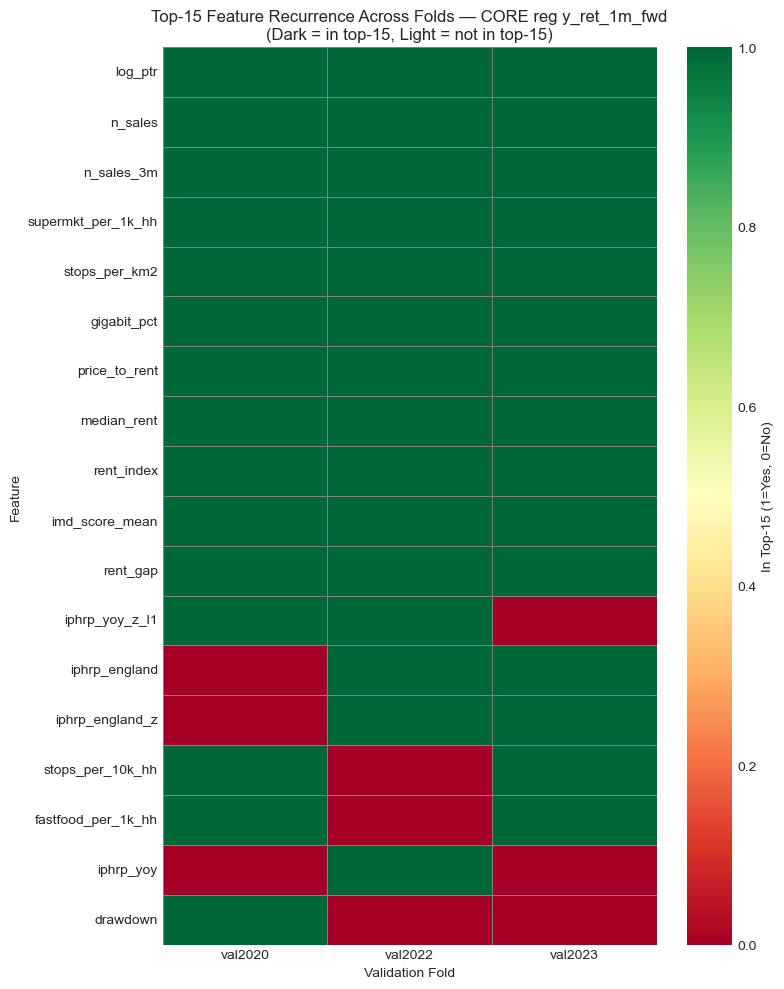


Recurrence Count Table (how many folds each feature appears in top-15):


,feature,folds_in_top15,pct_folds
0,log_ptr,3,100.0
1,price_to_rent,3,100.0
2,rent_gap,3,100.0
3,n_sales,3,100.0
4,rent_index,3,100.0
5,median_rent,3,100.0
6,imd_score_mean,3,100.0
7,gigabit_pct,3,100.0
8,stops_per_km2,3,100.0
9,supermkt_per_1k_hh,3,100.0



 Top-15 Recurrence Heatmap — CORE reg y_ret_3m_fwd 
Features appearing in top-15 across 3 folds
Features shown: 16 (those appearing at least once)

Recurrence Summary:
   Always in top-15 (3/3 folds): 14 features
   Often in top-15 (≥1/3 folds): 16 features
   Sometimes in top-15 (1-0/3 folds): 0 features

   Most stable features (appear in all folds):
      log_ptr
      rent_gap
      imd_score_mean
      rent_index
      iphrp_england
      iphrp_yoy
      median_rent
      n_sales
      stops_per_km2
      gigabit_pct


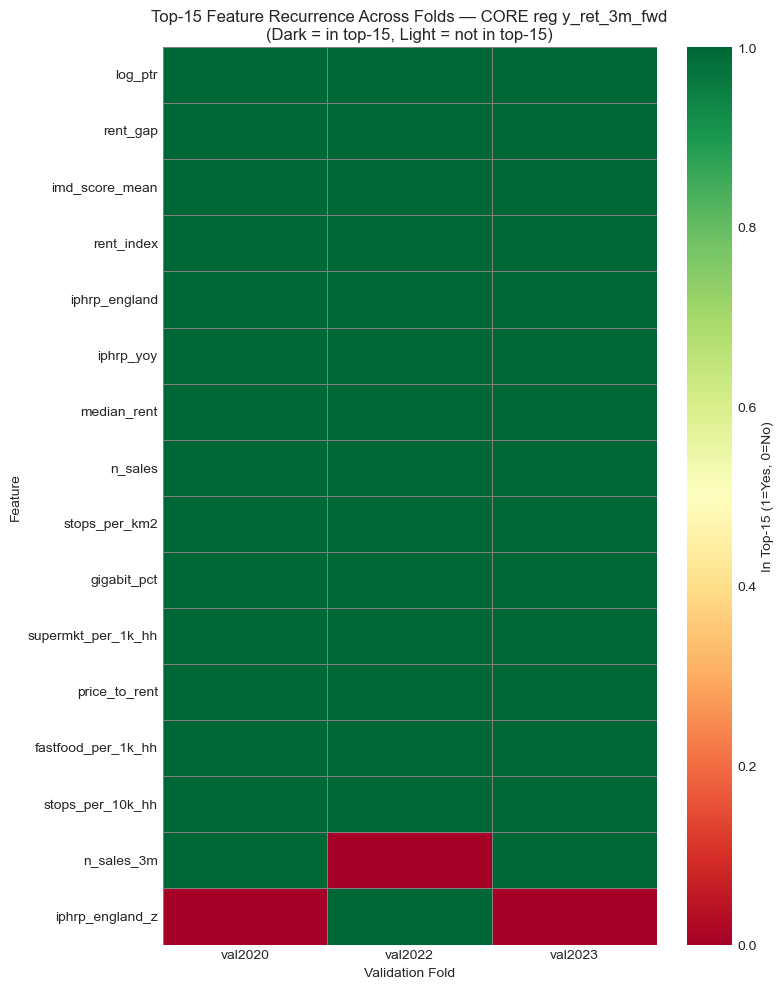


Recurrence Count Table (how many folds each feature appears in top-15):


,feature,folds_in_top15,pct_folds
0,log_ptr,3,100.0
1,rent_gap,3,100.0
2,imd_score_mean,3,100.0
3,rent_index,3,100.0
4,iphrp_england,3,100.0
5,iphrp_yoy,3,100.0
6,median_rent,3,100.0
7,n_sales,3,100.0
8,stops_per_km2,3,100.0
9,gigabit_pct,3,100.0



 Top-15 Recurrence Heatmap — CORE cls y_up_1m 
Features appearing in top-15 across 3 folds
Features shown: 19 (those appearing at least once)

Recurrence Summary:
   Always in top-15 (3/3 folds): 11 features
   Often in top-15 (≥1/3 folds): 19 features
   Sometimes in top-15 (1-0/3 folds): 0 features

   Most stable features (appear in all folds):
      log_ptr
      fastfood_per_1k_hh
      imd_score_mean
      n_sales_3m
      rent_index
      n_sales
      iphrp_england
      supermkt_per_1k_hh
      rent_gap
      median_rent


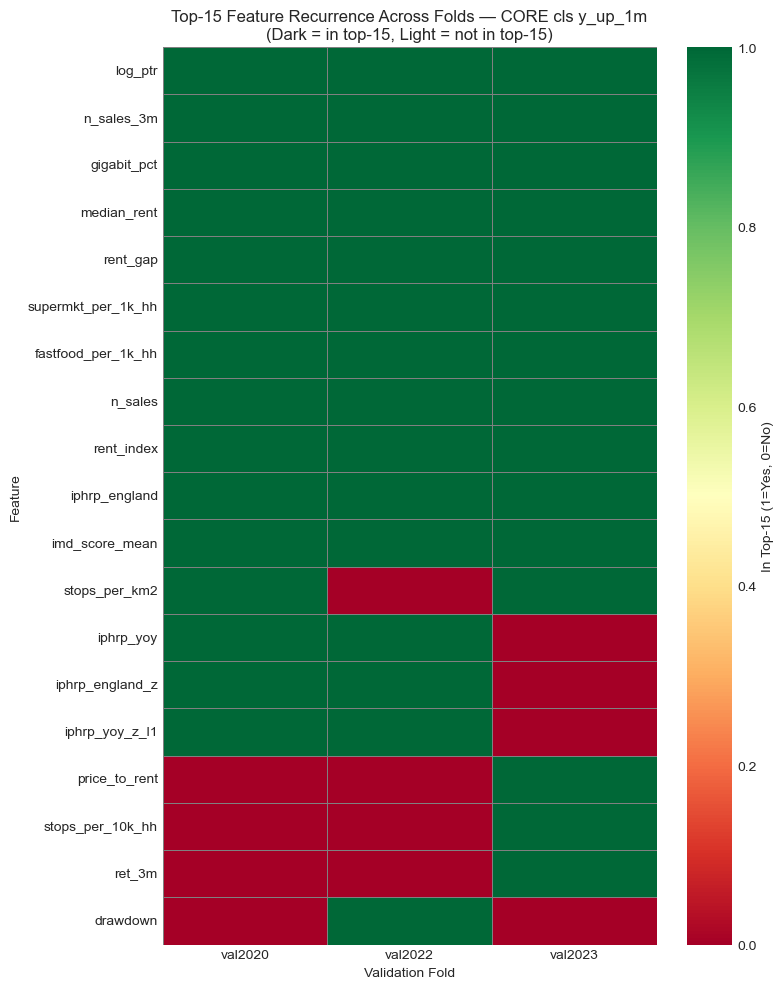


Recurrence Count Table (how many folds each feature appears in top-15):


,feature,folds_in_top15,pct_folds
0,log_ptr,3,100.0
1,fastfood_per_1k_hh,3,100.0
2,imd_score_mean,3,100.0
3,n_sales_3m,3,100.0
4,rent_index,3,100.0
5,n_sales,3,100.0
6,iphrp_england,3,100.0
7,supermkt_per_1k_hh,3,100.0
8,rent_gap,3,100.0
9,median_rent,3,100.0



 Top-15 Recurrence Heatmap — CORE cls y_up_3m 
Features appearing in top-15 across 3 folds
Features shown: 21 (those appearing at least once)

Recurrence Summary:
   Always in top-15 (3/3 folds): 10 features
   Often in top-15 (≥1/3 folds): 21 features
   Sometimes in top-15 (1-0/3 folds): 0 features

   Most stable features (appear in all folds):
      log_ptr
      supermkt_per_1k_hh
      stops_per_10k_hh
      iphrp_yoy_z_l1
      rent_gap
      median_rent
      rent_index
      imd_score_mean
      iphrp_england
      iphrp_yoy


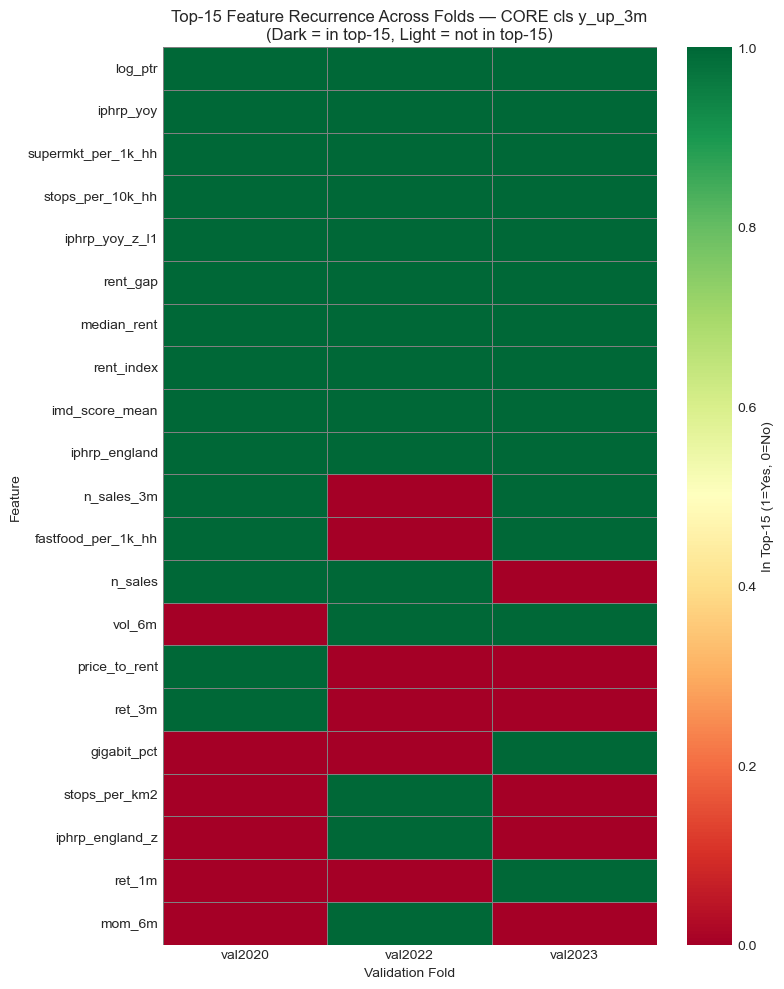


Recurrence Count Table (how many folds each feature appears in top-15):


,feature,folds_in_top15,pct_folds
0,log_ptr,3,100.0
1,supermkt_per_1k_hh,3,100.0
2,stops_per_10k_hh,3,100.0
3,iphrp_yoy_z_l1,3,100.0
4,rent_gap,3,100.0
5,median_rent,3,100.0
6,rent_index,3,100.0
7,imd_score_mean,3,100.0
8,iphrp_england,3,100.0
9,iphrp_yoy,3,100.0



 Top-15 Recurrence Heatmap — WITHRENT reg y_ret_1m_fwd 
Features appearing in top-15 across 3 folds
Features shown: 18 (those appearing at least once)

Recurrence Summary:
   Always in top-15 (3/3 folds): 11 features
   Often in top-15 (≥1/3 folds): 18 features
   Sometimes in top-15 (1-0/3 folds): 0 features

   Most stable features (appear in all folds):
      rent_gap
      stops_per_km2
      log_ptr
      iphrp_england
      gigabit_pct
      median_rent
      imd_score_mean
      stops_per_10k_hh
      supermkt_per_1k_hh
      fastfood_per_1k_hh


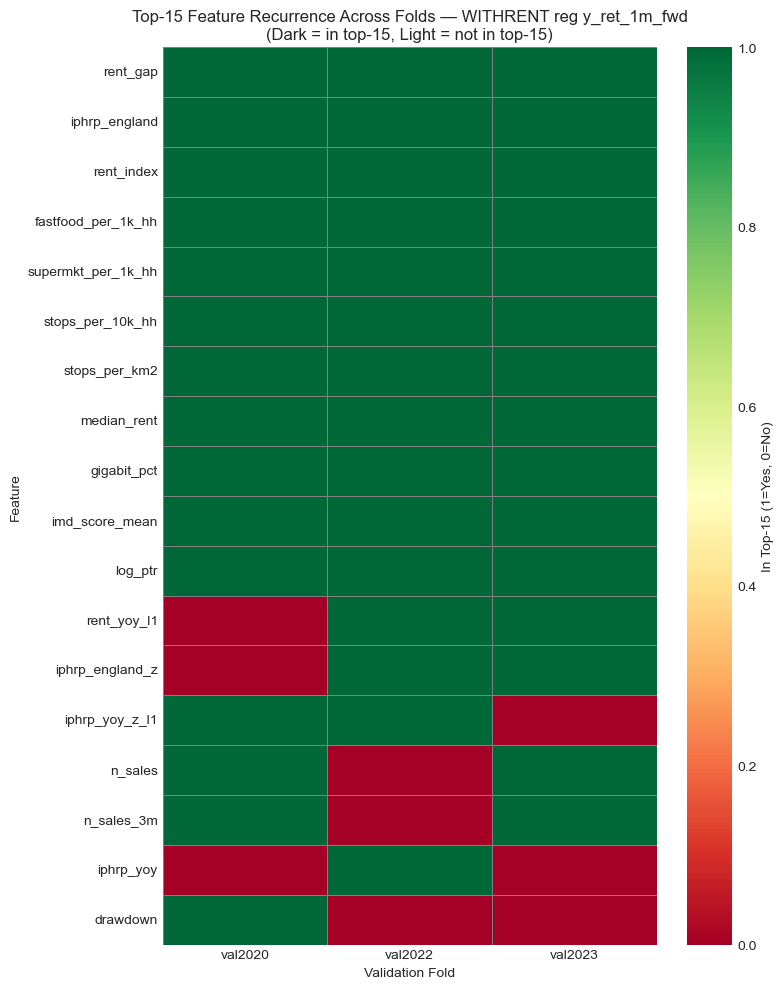


Recurrence Count Table (how many folds each feature appears in top-15):


,feature,folds_in_top15,pct_folds
0,rent_gap,3,100.0
1,stops_per_km2,3,100.0
2,log_ptr,3,100.0
3,iphrp_england,3,100.0
4,gigabit_pct,3,100.0
5,median_rent,3,100.0
6,imd_score_mean,3,100.0
7,stops_per_10k_hh,3,100.0
8,supermkt_per_1k_hh,3,100.0
9,fastfood_per_1k_hh,3,100.0



 Top-15 Recurrence Heatmap — WITHRENT reg y_ret_3m_fwd 
Features appearing in top-15 across 3 folds
Features shown: 19 (those appearing at least once)

Recurrence Summary:
   Always in top-15 (3/3 folds): 11 features
   Often in top-15 (≥1/3 folds): 19 features
   Sometimes in top-15 (1-0/3 folds): 0 features

   Most stable features (appear in all folds):
      rent_gap
      supermkt_per_1k_hh
      imd_score_mean
      gigabit_pct
      log_ptr
      rent_index
      iphrp_england
      median_rent
      stops_per_km2
      stops_per_10k_hh


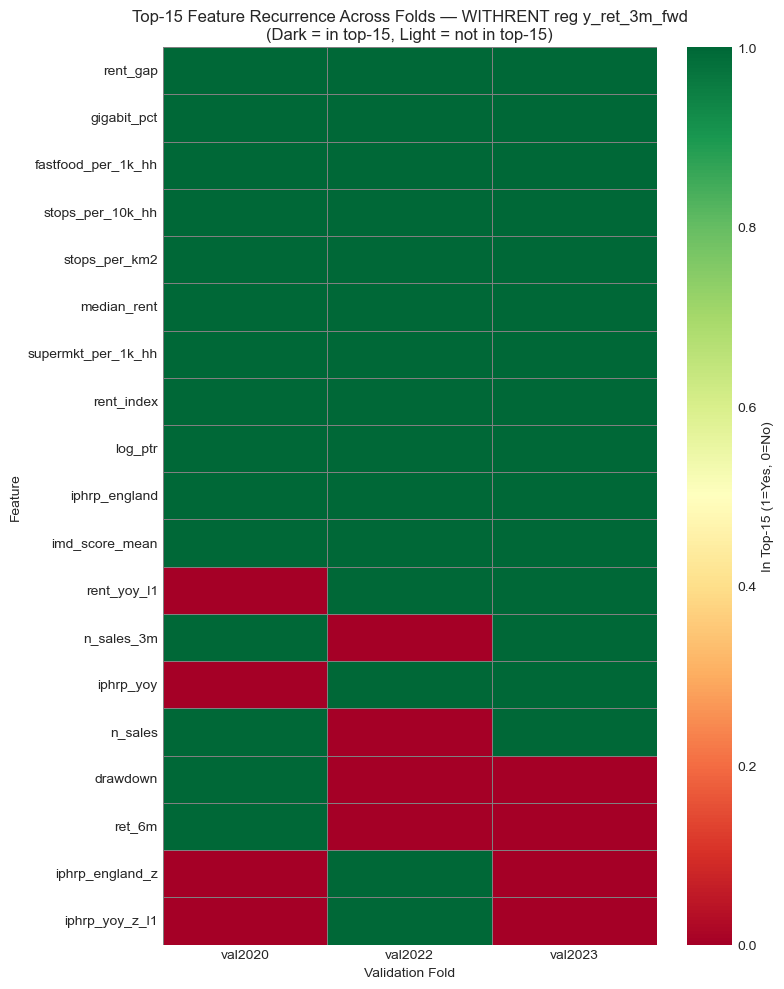


Recurrence Count Table (how many folds each feature appears in top-15):


,feature,folds_in_top15,pct_folds
0,rent_gap,3,100.0
1,supermkt_per_1k_hh,3,100.0
2,imd_score_mean,3,100.0
3,gigabit_pct,3,100.0
4,log_ptr,3,100.0
5,rent_index,3,100.0
6,iphrp_england,3,100.0
7,median_rent,3,100.0
8,stops_per_km2,3,100.0
9,stops_per_10k_hh,3,100.0



 Top-15 Recurrence Heatmap — WITHRENT cls y_up_1m 
Features appearing in top-15 across 3 folds
Features shown: 17 (those appearing at least once)

Recurrence Summary:
   Always in top-15 (3/3 folds): 11 features
   Often in top-15 (≥1/3 folds): 17 features
   Sometimes in top-15 (1-0/3 folds): 0 features

   Most stable features (appear in all folds):
      rent_gap
      gigabit_pct
      median_rent
      stops_per_km2
      fastfood_per_1k_hh
      imd_score_mean
      stops_per_10k_hh
      supermkt_per_1k_hh
      rent_index
      iphrp_england


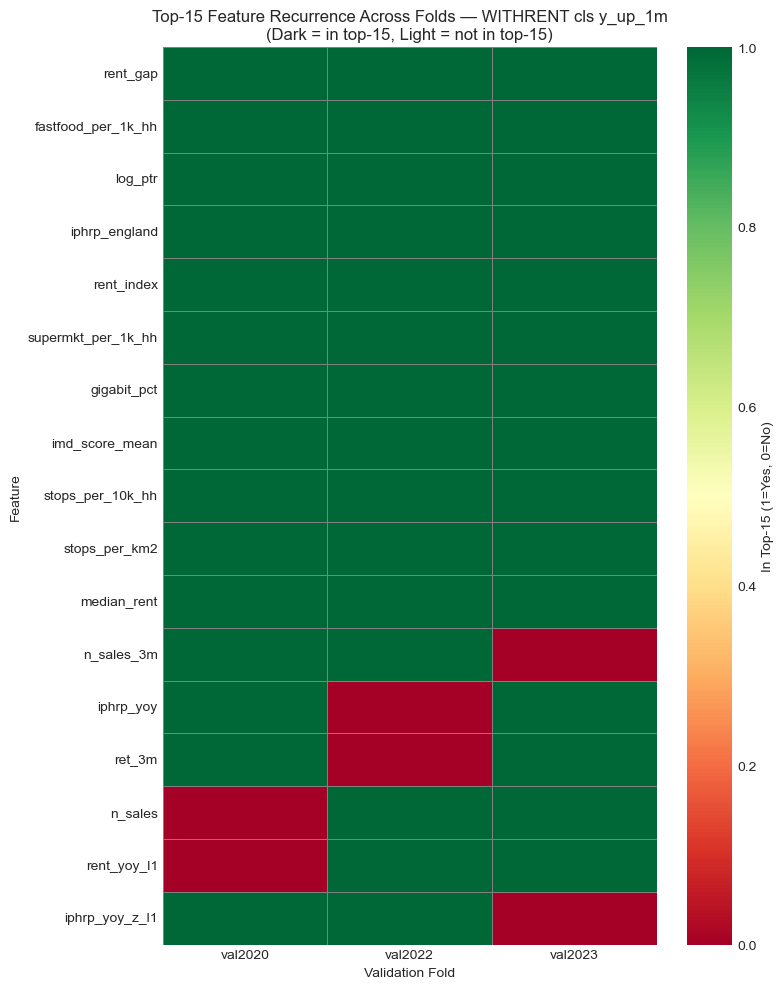


Recurrence Count Table (how many folds each feature appears in top-15):


,feature,folds_in_top15,pct_folds
0,rent_gap,3,100.0
1,gigabit_pct,3,100.0
2,median_rent,3,100.0
3,stops_per_km2,3,100.0
4,fastfood_per_1k_hh,3,100.0
5,imd_score_mean,3,100.0
6,stops_per_10k_hh,3,100.0
7,supermkt_per_1k_hh,3,100.0
8,rent_index,3,100.0
9,iphrp_england,3,100.0



 Top-15 Recurrence Heatmap — WITHRENT cls y_up_3m 
Features appearing in top-15 across 3 folds
Features shown: 20 (those appearing at least once)

Recurrence Summary:
   Always in top-15 (3/3 folds): 9 features
   Often in top-15 (≥1/3 folds): 20 features
   Sometimes in top-15 (1-0/3 folds): 0 features

   Most stable features (appear in all folds):
      rent_gap
      stops_per_10k_hh
      log_ptr
      stops_per_km2
      supermkt_per_1k_hh
      rent_yoy_l1
      iphrp_england
      imd_score_mean
      gigabit_pct


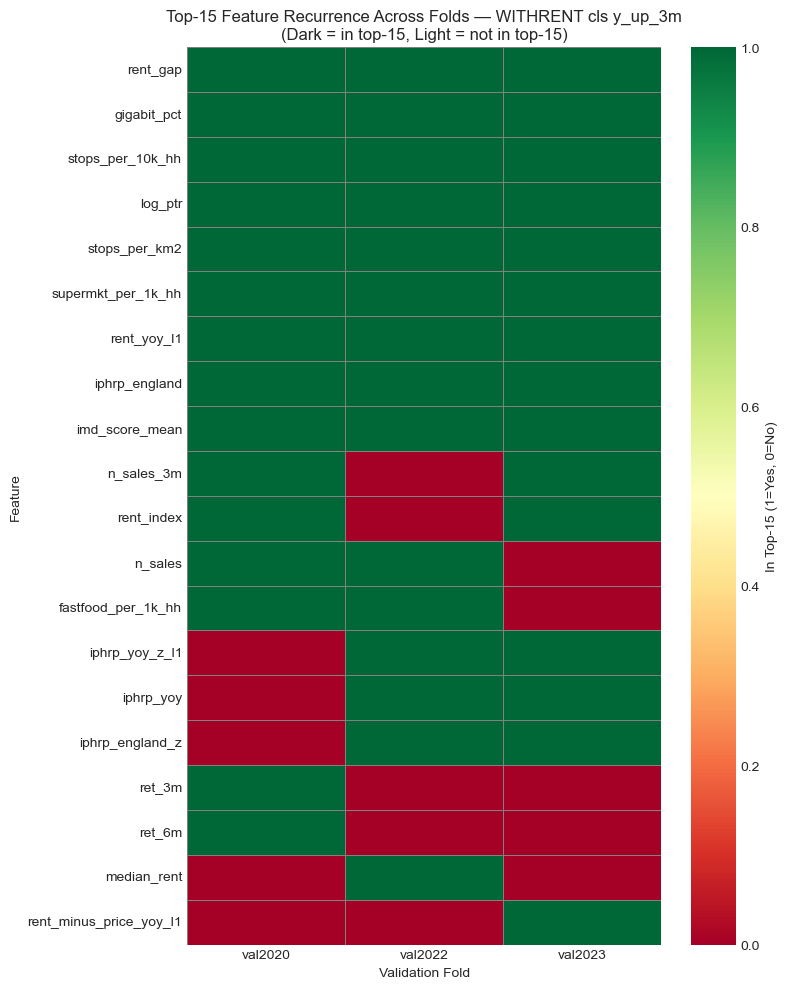


Recurrence Count Table (how many folds each feature appears in top-15):


,feature,folds_in_top15,pct_folds
0,rent_gap,3,100.0
1,stops_per_10k_hh,3,100.0
2,log_ptr,3,100.0
3,stops_per_km2,3,100.0
4,supermkt_per_1k_hh,3,100.0
5,rent_yoy_l1,3,100.0
6,iphrp_england,3,100.0
7,imd_score_mean,3,100.0
8,gigabit_pct,3,100.0
9,iphrp_yoy_z_l1,2,66.7


In [16]:
# Top-k Recurrence Heatmap (stability across folds)

def create_recurrence_heatmap(imp_df: pd.DataFrame, top_k=15):
    """Create heatmap showing feature recurrence in top-k across folds."""
    if imp_df.empty or 'fold' not in imp_df.columns:
        return pd.DataFrame()

    folds = sorted(imp_df['fold'].unique())
    all_features = imp_df['feature'].unique()

    recurrence_matrix = []
    for fold in folds:
        fold_data = imp_df[imp_df['fold'] == fold]
        top_k_features = fold_data.nlargest(top_k, 'abs_shap_mean')['feature'].values
        fold_vector = [1 if feat in top_k_features else 0 for feat in all_features]
        recurrence_matrix.append(fold_vector)

    recurrence_df = pd.DataFrame(
        recurrence_matrix,
        index=folds,
        columns=all_features
    ).T

    recurrence_df = recurrence_df[recurrence_df.sum(axis=1) > 0]
    recurrence_df['total'] = recurrence_df.sum(axis=1)
    recurrence_df = recurrence_df.sort_values('total', ascending=False).drop(columns=['total'])

    return recurrence_df

for variant in VARIANTS:
    for task, target in TASKS:
        key = f"{task}_{target}"
        if key not in all_sets[variant]:
            continue

        d = all_sets[variant][key]
        if d["imp"].empty:
            continue

        heatmap_data = create_recurrence_heatmap(d["imp"], top_k=15)

        if heatmap_data.empty:
            continue

        print(f"\n Top-15 Recurrence Heatmap — {variant} {task} {target} ")
        print(f"Features appearing in top-15 across {len(heatmap_data.columns)} folds")
        print(f"Features shown: {len(heatmap_data)} (those appearing at least once)")

        recurrence_counts = heatmap_data.sum(axis=1).sort_values(ascending=False)
        print(f"\nRecurrence Summary:")
        n_folds = len(heatmap_data.columns)
        print(f"   Always in top-15 ({n_folds}/{n_folds} folds): {len(recurrence_counts[recurrence_counts == n_folds])} features")
        print(f"   Often in top-15 (≥{n_folds//2}/{n_folds} folds): {len(recurrence_counts[recurrence_counts >= n_folds//2])} features")
        print(f"   Sometimes in top-15 (1-{n_folds//2-1}/{n_folds} folds): {len(recurrence_counts[recurrence_counts < n_folds//2])} features")

        stable = recurrence_counts[recurrence_counts == n_folds]
        if len(stable) > 0:
            print(f"\n   Most stable features (appear in all folds):")
            for feat in stable.head(10).index:
                print(f"      {feat}")

        # Heatmap (mirrors stocks style)
        plt.figure(figsize=(8, max(10, len(heatmap_data) * 0.4)))
        sns.heatmap(
            heatmap_data,
            annot=False,
            cmap='RdYlGn',
            cbar_kws={'label': 'In Top-15 (1=Yes, 0=No)'},
            linewidths=0.5,
            linecolor='gray',
            vmin=0,
            vmax=1
        )
        plt.title(f"Top-15 Feature Recurrence Across Folds — {variant} {task} {target}\n(Dark = in top-15, Light = not in top-15)")
        plt.xlabel("Validation Fold")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig(FIGS / f"shap_recurrence_{variant}_{task}_{target}.png", dpi=150, bbox_inches='tight')
        plt.show()

        # Recurrence count table
        print(f"\nRecurrence Count Table (how many folds each feature appears in top-15):")
        rec_table = pd.DataFrame({
            'feature': recurrence_counts.index,
            'folds_in_top15': recurrence_counts.values,
            'pct_folds': (recurrence_counts.values / n_folds * 100).round(1)
        })
        display(rec_table.head(20))

BINNED SHAP VS VALUE PLOTS
These plots show the relationship between feature values and SHAP contributions.
Negative slope = contrarian (higher feature value → lower probability)
Positive slope = momentum-following (higher feature value → higher probability)


=== CORE reg y_ret_1m_fwd — Top Features ===

Plotting binned relationships for: mom_3m, mom_6m, ret_1m, vol_6m


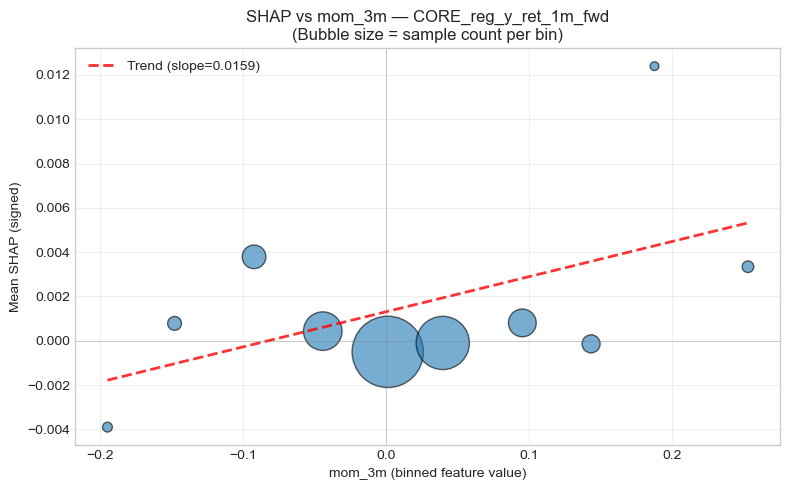


Interpretation for mom_3m:
   Positive relationship: Higher mom_3m → Higher probability (slope=0.0159)
   Bins: 10, Total samples: 600


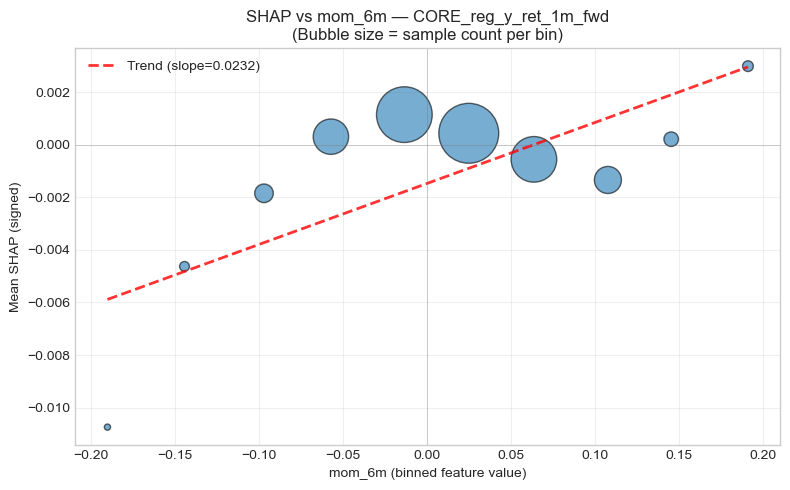


Interpretation for mom_6m:
   Positive relationship: Higher mom_6m → Higher probability (slope=0.0232)
   Bins: 10, Total samples: 600


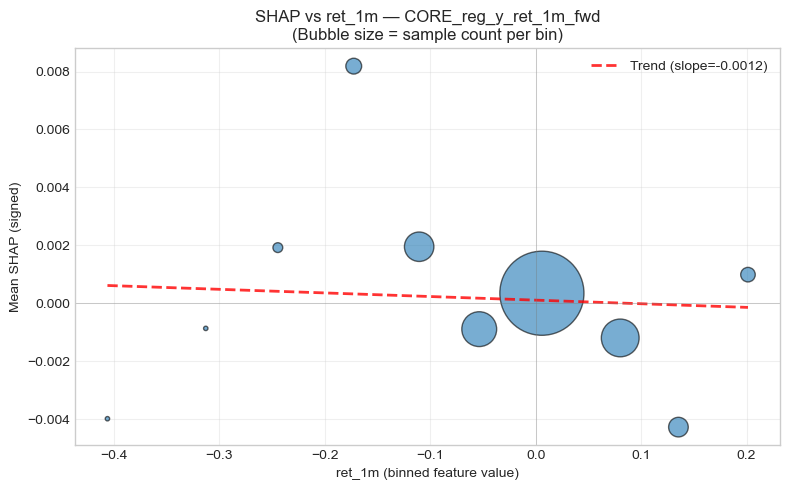


Interpretation for ret_1m:
   Negative relationship (CONTRARIAN): Higher ret_1m → Lower probability (slope=-0.0012)
   Bins: 10, Total samples: 600


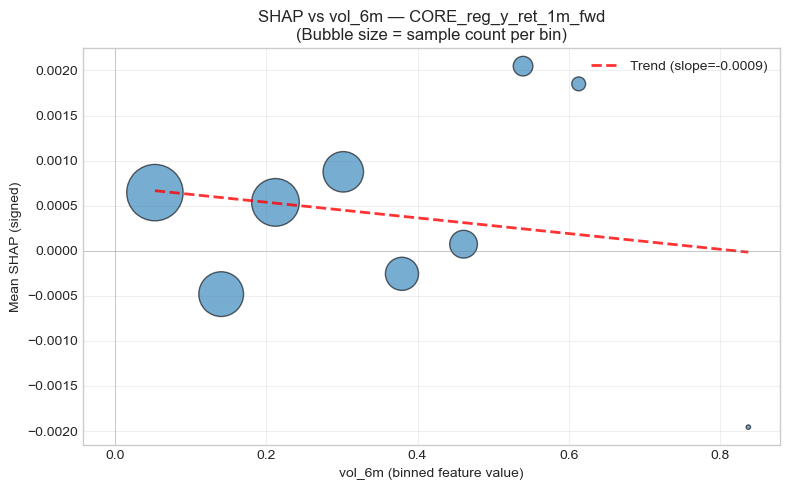


Interpretation for vol_6m:
   Weak relationship: slope=-0.0009 (close to zero)
   Bins: 9, Total samples: 600

=== CORE reg y_ret_3m_fwd — Top Features ===

Plotting binned relationships for: mom_3m, mom_6m, ret_1m, vol_6m


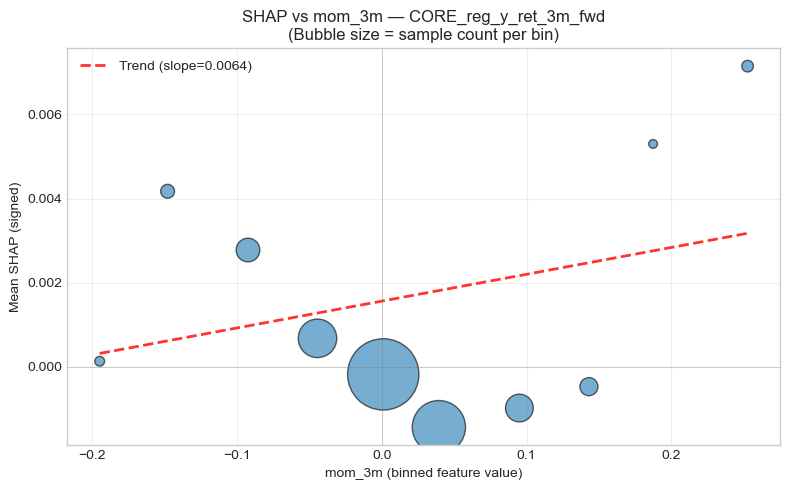


Interpretation for mom_3m:
   Positive relationship: Higher mom_3m → Higher probability (slope=0.0064)
   Bins: 10, Total samples: 600


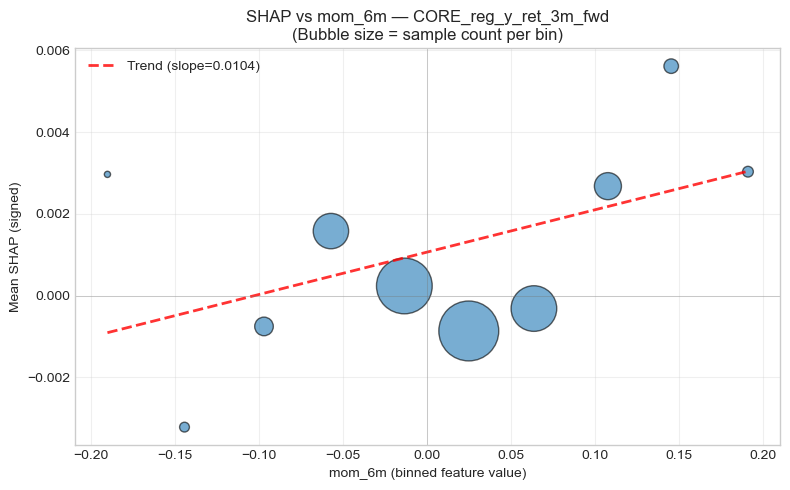


Interpretation for mom_6m:
   Positive relationship: Higher mom_6m → Higher probability (slope=0.0104)
   Bins: 10, Total samples: 600


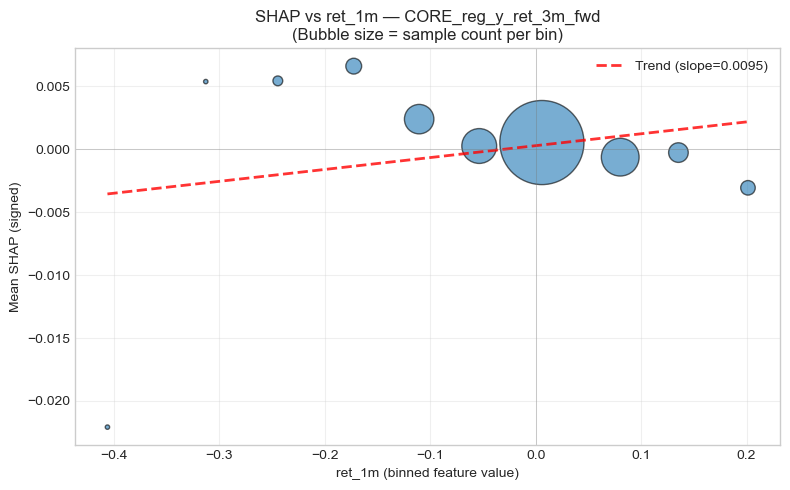


Interpretation for ret_1m:
   Positive relationship: Higher ret_1m → Higher probability (slope=0.0095)
   Bins: 10, Total samples: 600


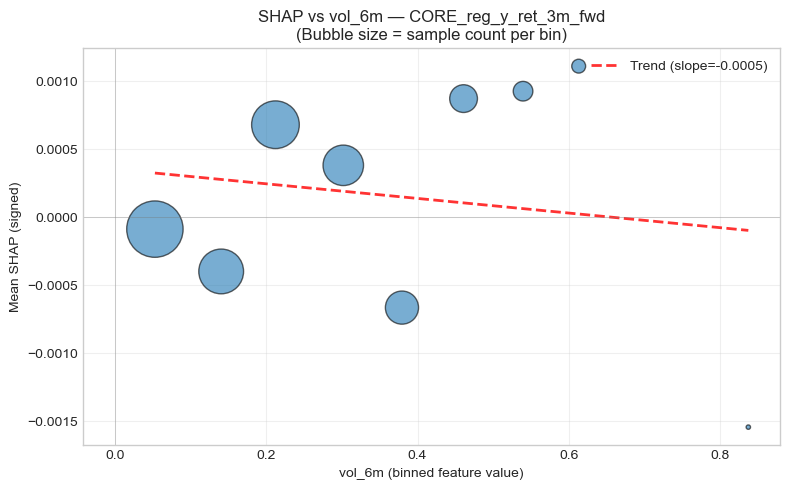


Interpretation for vol_6m:
   Weak relationship: slope=-0.0005 (close to zero)
   Bins: 9, Total samples: 600

=== CORE cls y_up_1m — Top Features ===

Plotting binned relationships for: mom_3m, mom_6m, ret_1m, vol_6m


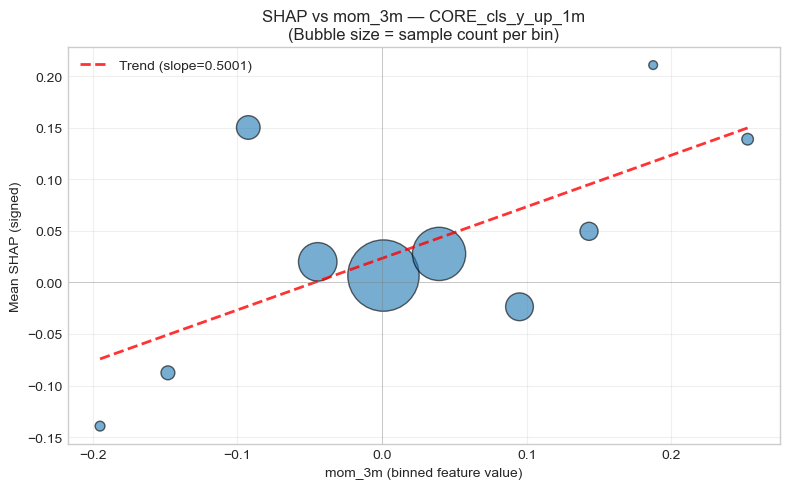


Interpretation for mom_3m:
   Positive relationship: Higher mom_3m → Higher probability (slope=0.5001)
   Bins: 10, Total samples: 600


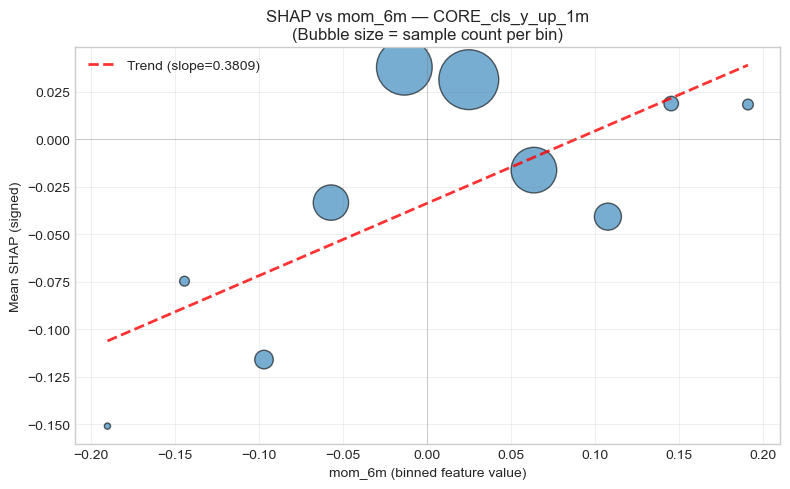


Interpretation for mom_6m:
   Positive relationship: Higher mom_6m → Higher probability (slope=0.3809)
   Bins: 10, Total samples: 600


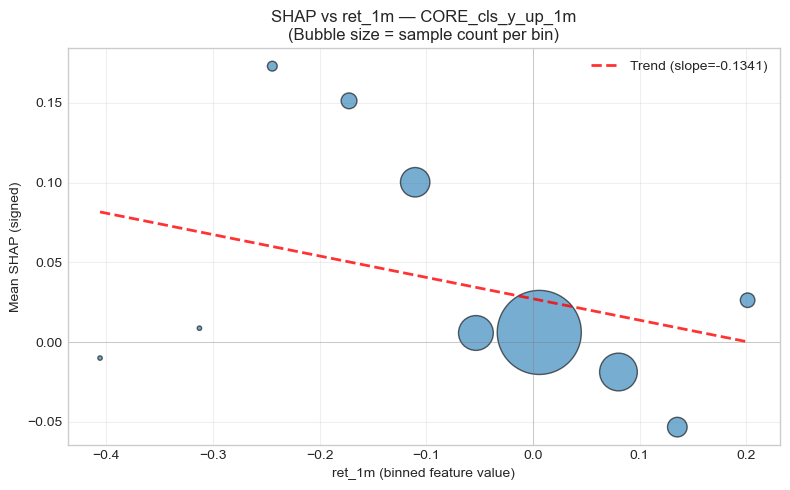


Interpretation for ret_1m:
   Negative relationship (CONTRARIAN): Higher ret_1m → Lower probability (slope=-0.1341)
   Bins: 10, Total samples: 600


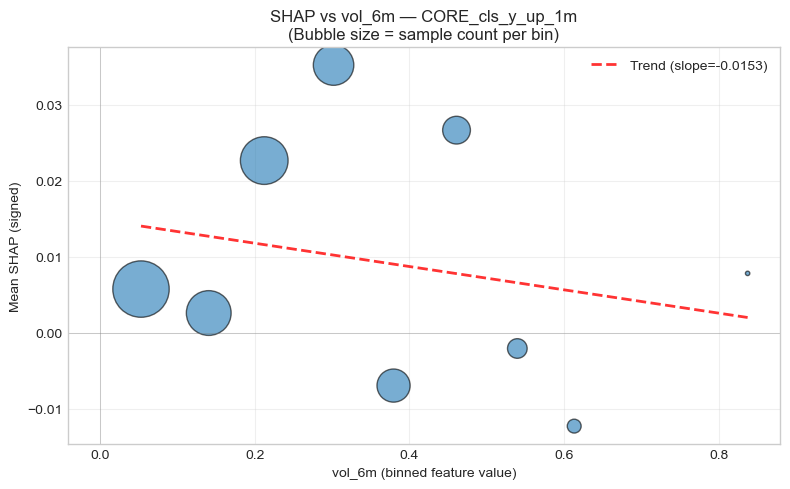


Interpretation for vol_6m:
   Negative relationship (CONTRARIAN): Higher vol_6m → Lower probability (slope=-0.0153)
   Bins: 9, Total samples: 600

=== CORE cls y_up_3m — Top Features ===

Plotting binned relationships for: mom_3m, mom_6m, ret_1m, vol_6m


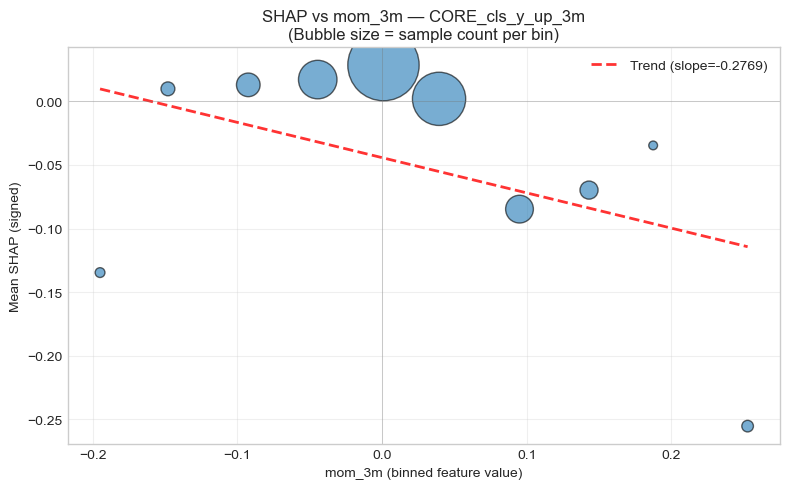


Interpretation for mom_3m:
   Negative relationship (CONTRARIAN): Higher mom_3m → Lower probability (slope=-0.2769)
   Bins: 10, Total samples: 600


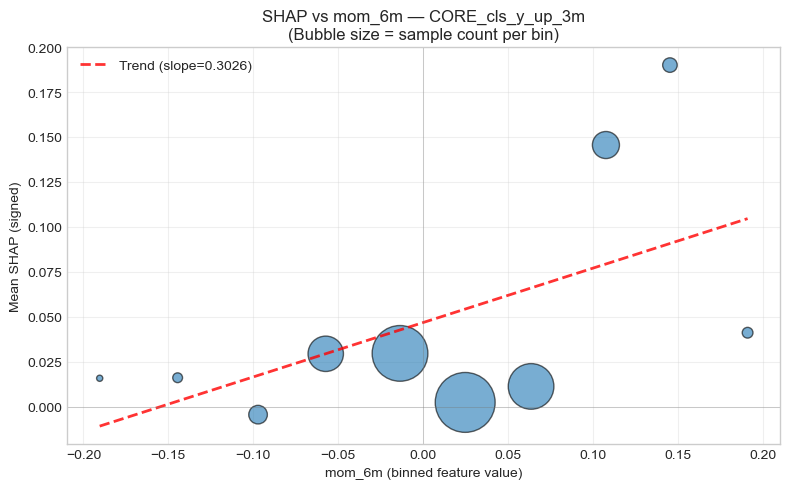


Interpretation for mom_6m:
   Positive relationship: Higher mom_6m → Higher probability (slope=0.3026)
   Bins: 10, Total samples: 600


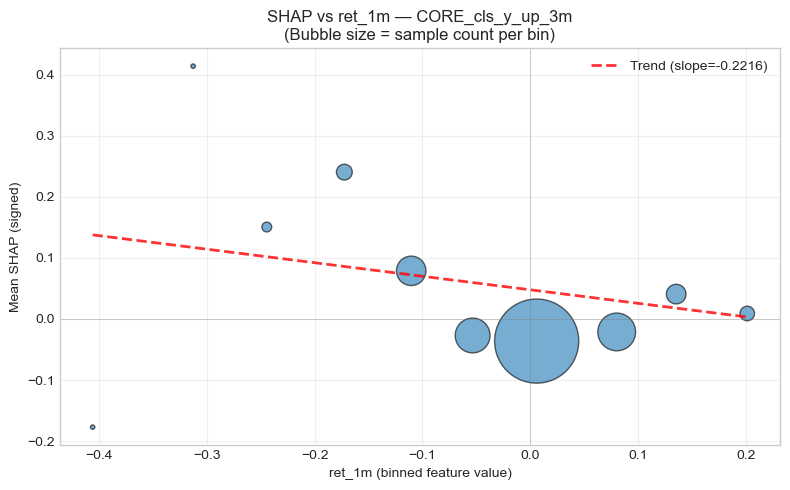


Interpretation for ret_1m:
   Negative relationship (CONTRARIAN): Higher ret_1m → Lower probability (slope=-0.2216)
   Bins: 10, Total samples: 600


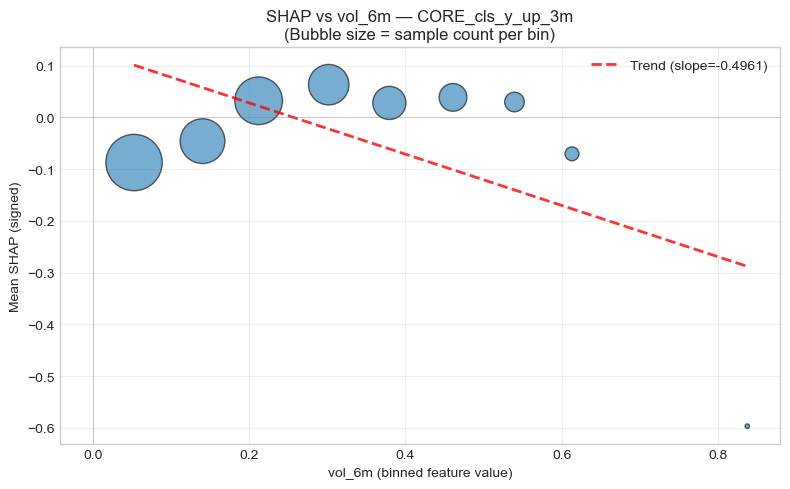


Interpretation for vol_6m:
   Negative relationship (CONTRARIAN): Higher vol_6m → Lower probability (slope=-0.4961)
   Bins: 9, Total samples: 600

=== WITHRENT reg y_ret_1m_fwd — Top Features ===

Plotting binned relationships for: mom_3m, mom_6m, ret_1m, vol_6m


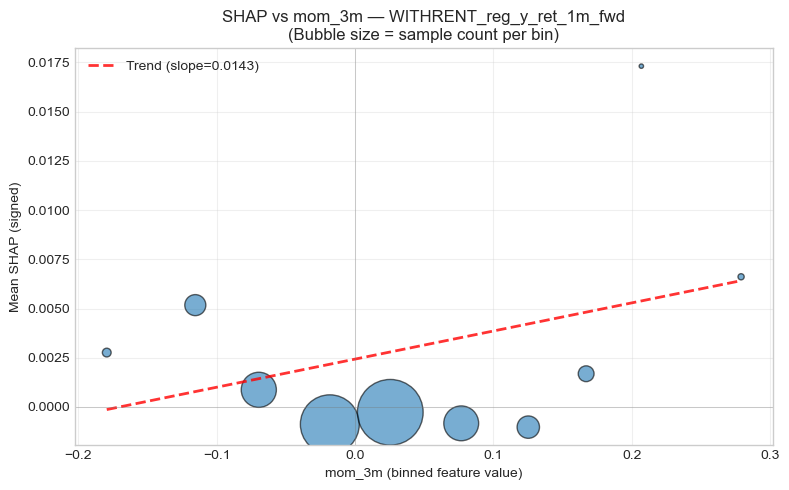


Interpretation for mom_3m:
   Positive relationship: Higher mom_3m → Higher probability (slope=0.0143)
   Bins: 10, Total samples: 600


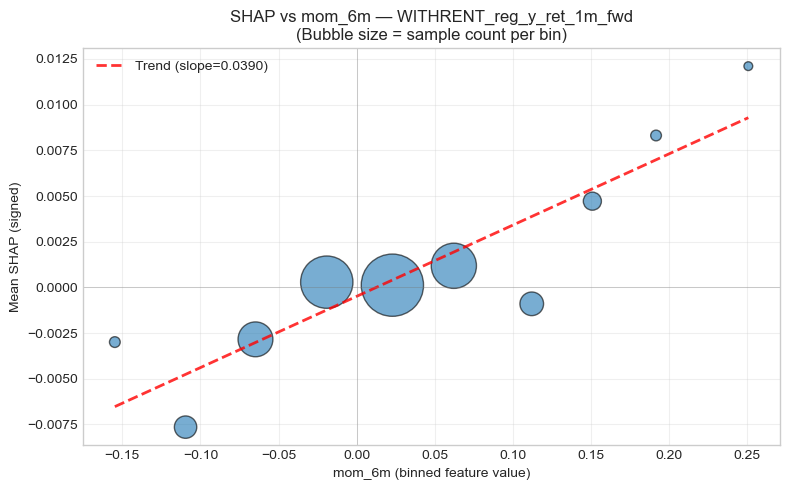


Interpretation for mom_6m:
   Positive relationship: Higher mom_6m → Higher probability (slope=0.0390)
   Bins: 10, Total samples: 600


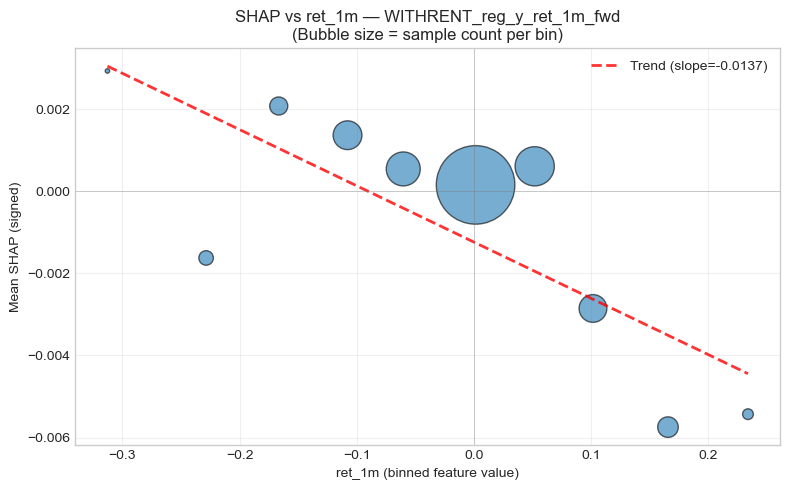


Interpretation for ret_1m:
   Negative relationship (CONTRARIAN): Higher ret_1m → Lower probability (slope=-0.0137)
   Bins: 10, Total samples: 600


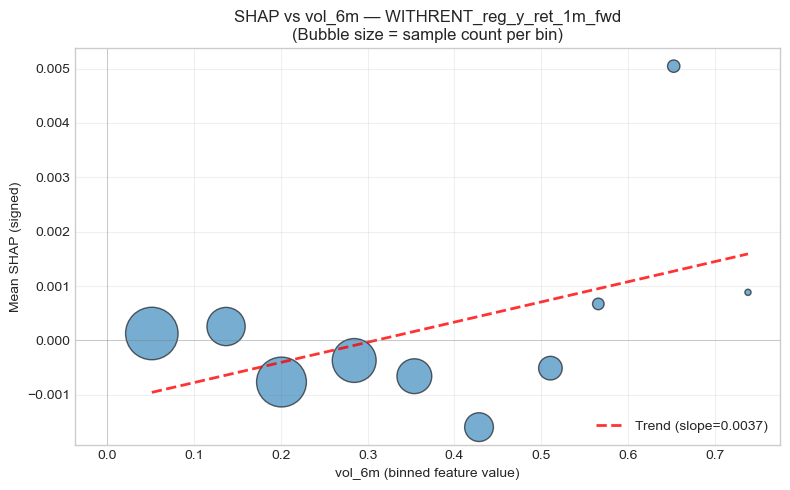


Interpretation for vol_6m:
   Positive relationship: Higher vol_6m → Higher probability (slope=0.0037)
   Bins: 10, Total samples: 600

=== WITHRENT reg y_ret_3m_fwd — Top Features ===

Plotting binned relationships for: mom_3m, mom_6m, ret_1m, vol_6m


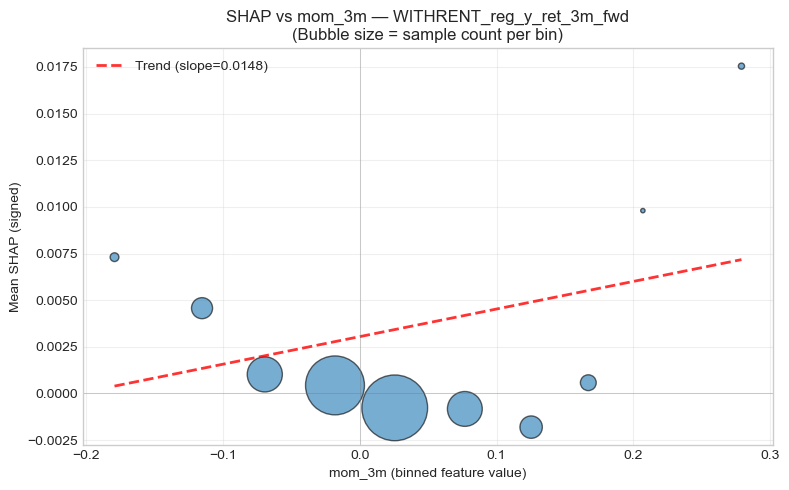


Interpretation for mom_3m:
   Positive relationship: Higher mom_3m → Higher probability (slope=0.0148)
   Bins: 10, Total samples: 600


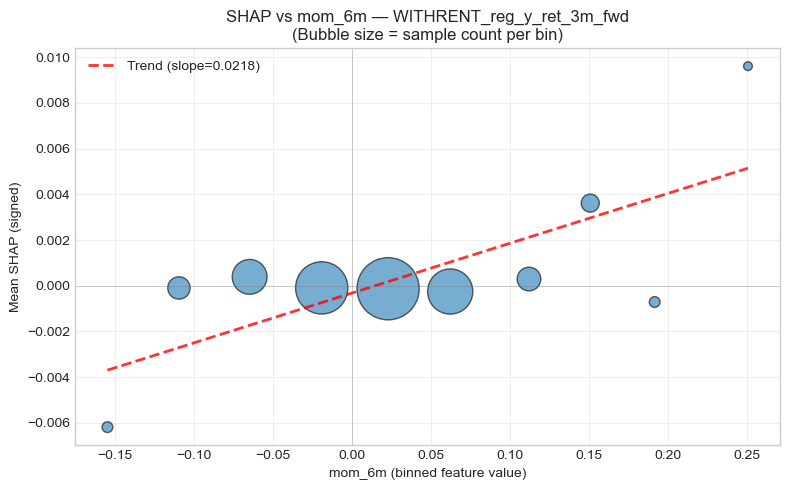


Interpretation for mom_6m:
   Positive relationship: Higher mom_6m → Higher probability (slope=0.0218)
   Bins: 10, Total samples: 600


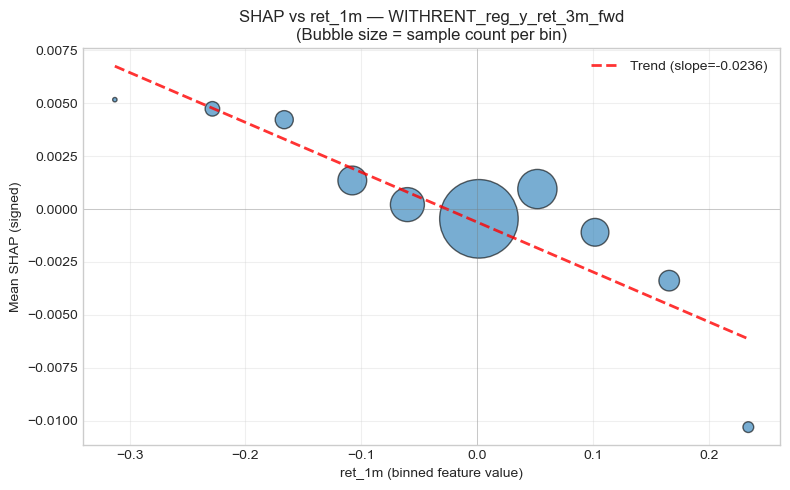


Interpretation for ret_1m:
   Negative relationship (CONTRARIAN): Higher ret_1m → Lower probability (slope=-0.0236)
   Bins: 10, Total samples: 600


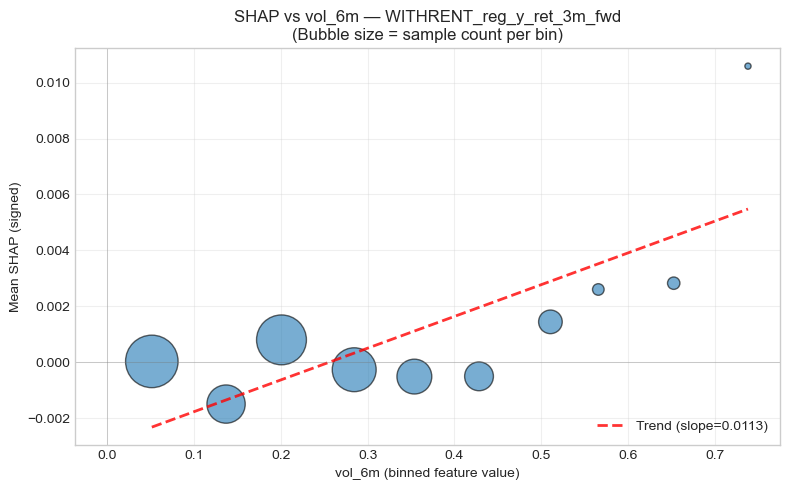


Interpretation for vol_6m:
   Positive relationship: Higher vol_6m → Higher probability (slope=0.0113)
   Bins: 10, Total samples: 600

=== WITHRENT cls y_up_1m — Top Features ===

Plotting binned relationships for: mom_3m, mom_6m, ret_1m, vol_6m


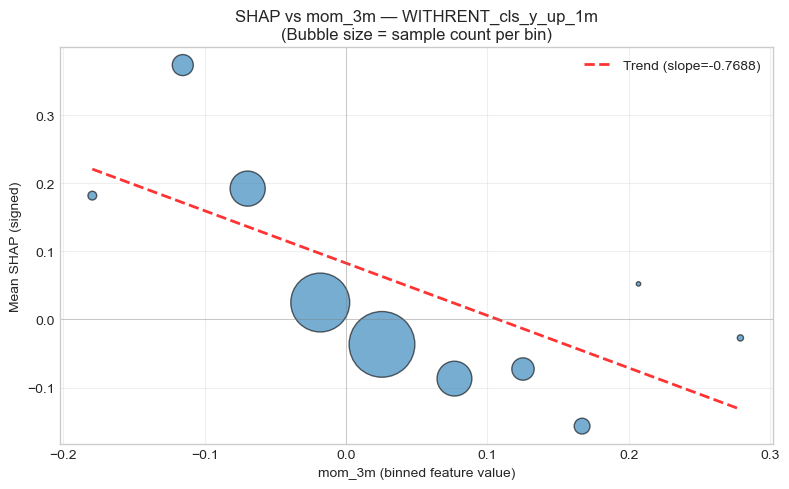


Interpretation for mom_3m:
   Negative relationship (CONTRARIAN): Higher mom_3m → Lower probability (slope=-0.7688)
   Bins: 10, Total samples: 600


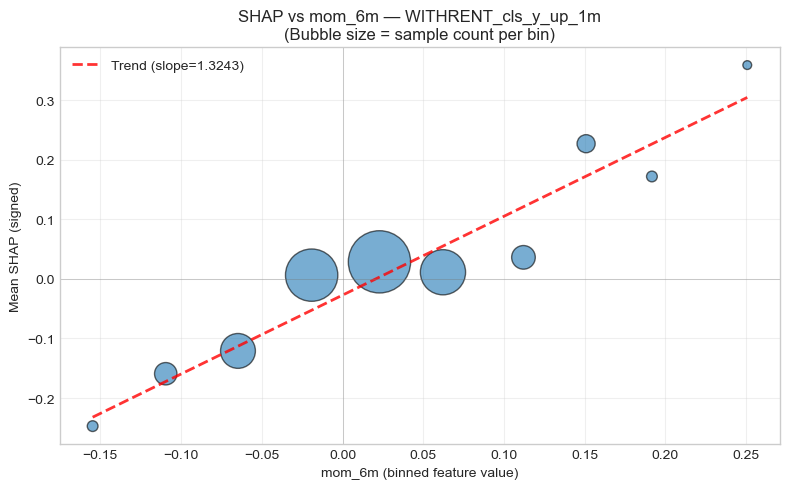


Interpretation for mom_6m:
   Positive relationship: Higher mom_6m → Higher probability (slope=1.3243)
   Bins: 10, Total samples: 600


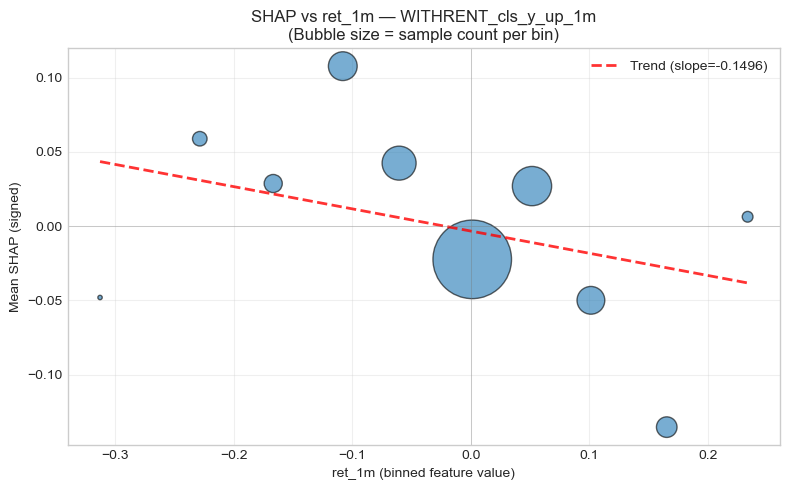


Interpretation for ret_1m:
   Negative relationship (CONTRARIAN): Higher ret_1m → Lower probability (slope=-0.1496)
   Bins: 10, Total samples: 600


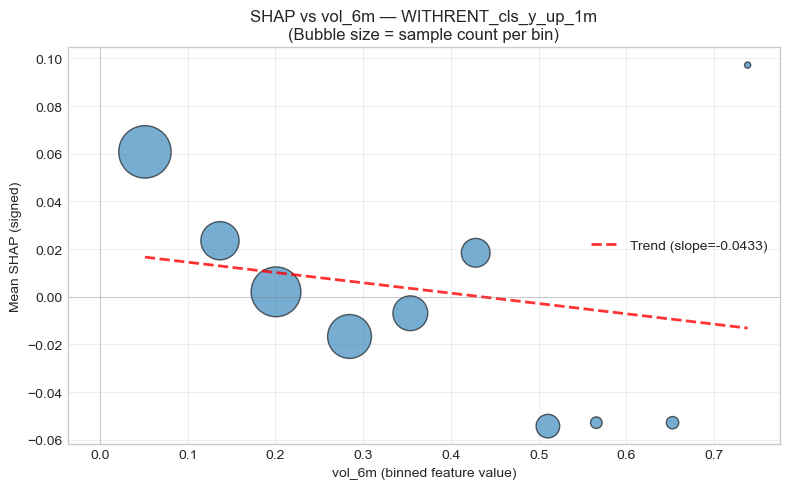


Interpretation for vol_6m:
   Negative relationship (CONTRARIAN): Higher vol_6m → Lower probability (slope=-0.0433)
   Bins: 10, Total samples: 600

=== WITHRENT cls y_up_3m — Top Features ===

Plotting binned relationships for: mom_3m, mom_6m, ret_1m, vol_6m


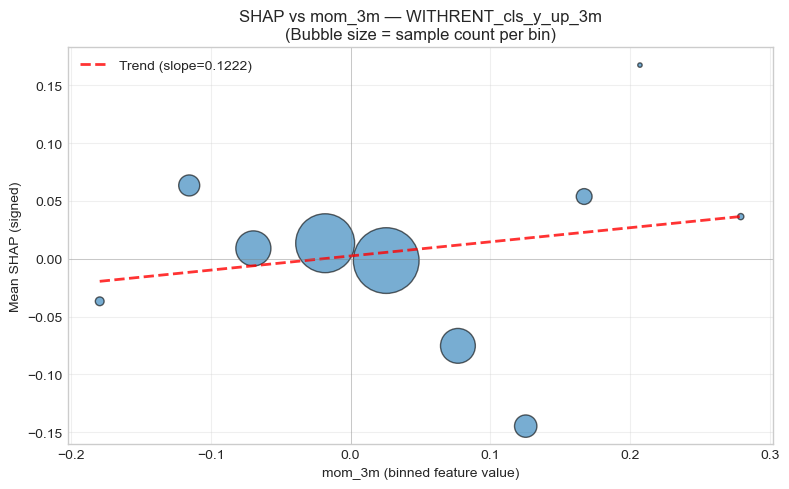


Interpretation for mom_3m:
   Positive relationship: Higher mom_3m → Higher probability (slope=0.1222)
   Bins: 10, Total samples: 600


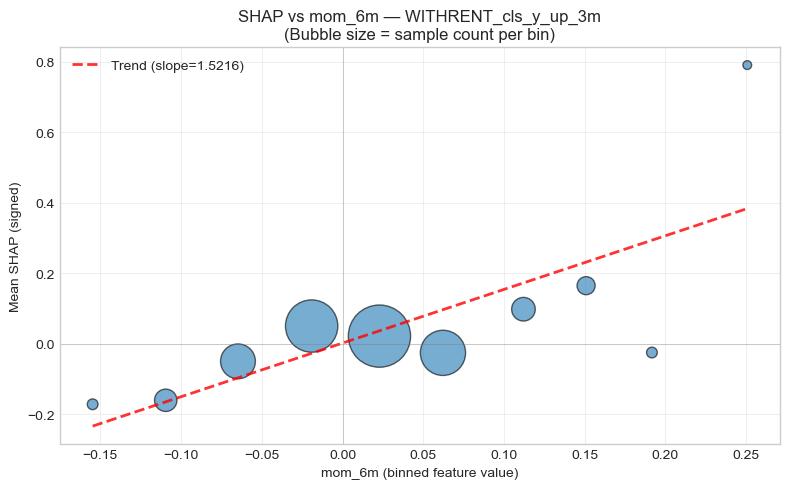


Interpretation for mom_6m:
   Positive relationship: Higher mom_6m → Higher probability (slope=1.5216)
   Bins: 10, Total samples: 600


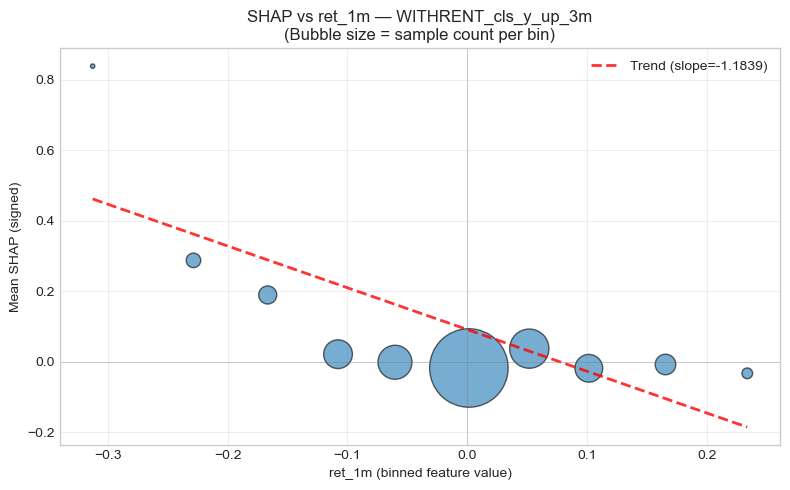


Interpretation for ret_1m:
   Negative relationship (CONTRARIAN): Higher ret_1m → Lower probability (slope=-1.1839)
   Bins: 10, Total samples: 600


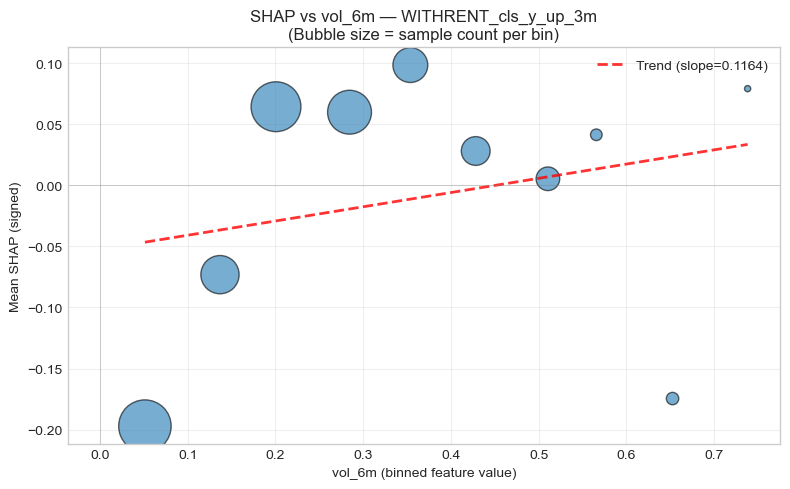


Interpretation for vol_6m:
   Positive relationship: Higher vol_6m → Higher probability (slope=0.1164)
   Bins: 10, Total samples: 600


In [18]:
# Binned SHAP vs Value Plots (shows directionality)


def plot_binned_shap_vs_value(rec_df: pd.DataFrame, feature: str, n_bins=10, tag: str = ""):
    """Create binned plot showing relationship between feature values and SHAP contributions."""
    feat_data = rec_df[rec_df['feature'] == feature].copy()

    if len(feat_data) == 0:
        print(f"No data for feature: {feature}")
        return

    # Bin by feature value
    feat_data['bin'] = pd.cut(feat_data['mean_val'], bins=n_bins, labels=False, duplicates='drop')
    bin_stats = feat_data.groupby('bin').agg({
        'mean_shap': 'mean',
        'mean_val': ['mean', 'min', 'max', 'count']
    }).reset_index()

    bin_stats.columns = ['bin', 'mean_shap', 'mean_val', 'val_min', 'val_max', 'count']
    bin_stats = bin_stats.dropna()

    if len(bin_stats) < 2:
        print(f"Not enough bins for feature: {feature}")
        return

    # Create plot 
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(bin_stats['mean_val'], bin_stats['mean_shap'],
              s=bin_stats['count'] * 10, alpha=0.6, edgecolors='black', linewidth=1)

    # Trend line
    z = np.polyfit(bin_stats['mean_val'], bin_stats['mean_shap'], 1)
    p = np.poly1d(z)
    ax.plot(bin_stats['mean_val'], p(bin_stats['mean_val']),
           "r--", alpha=0.8, linewidth=2, label=f'Trend (slope={z[0]:.4f})')

    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.set_xlabel(f'{feature} (binned feature value)')
    ax.set_ylabel('Mean SHAP (signed)')
    ax.set_title(f'SHAP vs {feature} — {tag}\n(Bubble size = sample count per bin)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGS / f"shap_binned_{tag}_{feature.replace('/', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Interpretation
    slope = z[0]
    print(f"\nInterpretation for {feature}:")
    if slope > 0.001:
        print(f"   Positive relationship: Higher {feature} → Higher probability (slope={slope:.4f})")
    elif slope < -0.001:
        print(f"   Negative relationship (CONTRARIAN): Higher {feature} → Lower probability (slope={slope:.4f})")
    else:
        print(f"   Weak relationship: slope={slope:.4f} (close to zero)")
    print(f"   Bins: {len(bin_stats)}, Total samples: {feat_data['mean_val'].count()}")

# Plot key features 
print("="*70)
print("BINNED SHAP VS VALUE PLOTS")
print("="*70)
print("These plots show the relationship between feature values and SHAP contributions.")
print("Negative slope = contrarian (higher feature value → lower probability)")
print("Positive slope = momentum-following (higher feature value → higher probability)")
print()

for variant in VARIANTS:
    for task, target in TASKS:
        key = f"{task}_{target}"
        if key not in all_sets[variant]:
            continue

        d = all_sets[variant][key]
        if d["rec"].empty:
            print(f"\n{variant} {key}: No recipe data available (row-level SHAP files not found)")
            continue

        # Get top features
        top_features = d["imp"].groupby("feature")["abs_shap_mean"].mean().sort_values(ascending=False).head(5)

        print(f"\n{'='*70}")
        print(f"=== {variant} {task} {target} — Top Features ===")
        print(f"{'='*70}")

        # Plot key features that might show interesting patterns
        key_features = ['mom_3m', 'mom_6m', 'ret_1m', 'vol_6m', 'price_to_rent', 'rent_yoy_l1']
        available_features = [f for f in key_features if f in d["rec"]['feature'].unique()]

        if not available_features:
            available_features = top_features.index.tolist()[:4]

        print(f"\nPlotting binned relationships for: {', '.join(available_features[:4])}")

        for feat in available_features[:4]:
            plot_binned_shap_vs_value(d["rec"], feat, n_bins=10, tag=f"{variant}_{task}_{target}")

In [19]:
# Recipe for Success Table (top-decile winners)

def recipe_table(rec_df: pd.DataFrame, top_k=15):
    """Create recipe table: average signed SHAP and feature values for top-decile predictions."""
    if rec_df.empty:
        return pd.DataFrame(columns=["feature", "mean_shap", "mean_val"])

    g = (rec_df.groupby("feature", as_index=False)[["mean_shap", "mean_val"]].mean())
    # Rank by absolute SHAP 
    g["rank_key"] = g["mean_shap"].abs()
    g = g.sort_values("rank_key", ascending=False).drop(columns=["rank_key"])
    return g.head(top_k)

for variant in VARIANTS:
    for task, target in TASKS:
        key = f"{task}_{target}"
        if key not in all_sets[variant]:
            continue

        d = all_sets[variant][key]
        if d["rec"].empty:
            continue

        rec_tbl = recipe_table(d["rec"], top_k=20)
        if rec_tbl.empty:
            continue

        print(f"\n Recipe for Success — {variant} {task} {target} ")
        print("(Top-decile predicted winners: avg signed SHAP + avg raw feature value)")
        display(rec_tbl)

        # Save to CSV for easy reference
        rec_tbl.to_csv(TABLES / f"recipe_{variant}_{task}_{target}.csv", index=False)
        print(f"Saved recipe table {TABLES / f'recipe_{variant}_{task}_{target}.csv'}")


 Recipe for Success — CORE reg y_ret_1m_fwd 
(Top-decile predicted winners: avg signed SHAP + avg raw feature value)


,feature,mean_shap,mean_val
13,log_ptr,-0.040065,3.264781
9,iphrp_england,0.020823,97.476578
22,rent_index,0.005922,1139.036987
12,iphrp_yoy_z_l1,0.004267,0.157849
19,price_to_rent,-0.003995,26.526009
10,iphrp_england_z,0.003082,0.216591
21,rent_gap,0.003066,5.570435
11,iphrp_yoy,-0.002481,0.043647
7,imd_score_mean,-0.002333,19.868223
18,n_sales_3m,0.001968,673.784973


Saved recipe table ../../reports/property/tables/recipe_CORE_reg_y_ret_1m_fwd.csv

 Recipe for Success — CORE reg y_ret_3m_fwd 
(Top-decile predicted winners: avg signed SHAP + avg raw feature value)


,feature,mean_shap,mean_val
13,log_ptr,-0.045430,3.264781
9,iphrp_england,0.016961,97.476578
22,rent_index,0.007051,1139.036987
11,iphrp_yoy,-0.005154,0.043647
19,price_to_rent,-0.004198,26.526009
21,rent_gap,0.003125,5.570435
10,iphrp_england_z,0.002847,0.216591
18,n_sales_3m,0.002166,673.784973
7,imd_score_mean,-0.002015,19.868223
3,drawdown,0.001224,-0.069996


Saved recipe table ../../reports/property/tables/recipe_CORE_reg_y_ret_3m_fwd.csv

 Recipe for Success — CORE cls y_up_1m 
(Top-decile predicted winners: avg signed SHAP + avg raw feature value)


...

Saved recipe table ../../reports/property/tables/recipe_WITHRENT_reg_y_ret_3m_fwd.csv

 Recipe for Success — WITHRENT cls y_up_1m 
(Top-decile predicted winners: avg signed SHAP + avg raw feature value)


,feature,mean_shap,mean_val
10,iphrp_england,0.491330,97.426811
22,rent_gap,-0.460220,5.579156
14,log_ptr,-0.426661,3.271863
25,rent_yoy_l1,-0.254319,0.040470
13,iphrp_yoy_z_l1,-0.094983,0.146445
19,n_sales_3m,0.063044,622.979980
20,price_to_rent,-0.054414,26.693710
12,iphrp_yoy,-0.038576,0.043359
8,imd_score_mean,-0.033215,19.325468
23,rent_index,0.031868,1173.870483


Saved recipe table ../../reports/property/tables/recipe_WITHRENT_cls_y_up_1m.csv

 Recipe for Success — WITHRENT cls y_up_3m 
(Top-decile predicted winners: avg signed SHAP + avg raw feature value)


,feature,mean_shap,mean_val
10,iphrp_england,0.889320,97.426811
12,iphrp_yoy,-0.584865,0.043359
22,rent_gap,-0.516036,5.579156
14,log_ptr,-0.394547,3.271863
13,iphrp_yoy_z_l1,-0.295676,0.146445
25,rent_yoy_l1,-0.295648,0.040470
11,iphrp_england_z,0.132201,0.211929
19,n_sales_3m,0.070638,622.979980
24,rent_minus_price_yoy_l1,0.064016,-0.003013
8,imd_score_mean,-0.057153,19.325468


Saved recipe table ../../reports/property/tables/recipe_WITHRENT_cls_y_up_3m.csv


In [22]:
# Summary Report

print("="*100)
print("PROPERTY SHAP ANALYSIS SUMMARY")
print("="*100)

for variant in VARIANTS:
    print(f"\n{variant} VARIANT:")
    for task, target in TASKS:
        key = f"{task}_{target}"
        if key not in all_sets[variant]:
            continue

        d = all_sets[variant][key]
        if d["imp"].empty:
            continue

        top5 = d["imp"].groupby("feature")["abs_shap_mean"].mean().sort_values(ascending=False).head(5)
        print(f"  {task} {target}:")
        print(f"    Top 5 features: {', '.join(top5.index.tolist())}")

        if not d["fam"].empty:
            fam_top = d["fam"].groupby("family")["mean_abs_shap"].mean().sort_values(ascending=False).head(3)
            print(f"    Top 3 families: {', '.join(fam_top.index.tolist())}")

print(f"\nAll visualizations saved to: {FIGS}")
print(f"Recipe tables saved to: {TABLES}")

PROPERTY SHAP ANALYSIS SUMMARY

CORE VARIANT:
  reg y_ret_1m_fwd:
    Top 5 features: log_ptr, rent_gap, iphrp_england, imd_score_mean, rent_index
    Top 3 families: rent_features, time_varying_context, other
  reg y_ret_3m_fwd:
    Top 5 features: log_ptr, rent_gap, iphrp_england, imd_score_mean, iphrp_yoy
    Top 3 families: rent_features, other, time_varying_context
  cls y_up_1m:
    Top 5 features: log_ptr, iphrp_england, rent_gap, imd_score_mean, iphrp_yoy_z_l1
    Top 3 families: rent_features, time_varying_context, other
  cls y_up_3m:
    Top 5 features: log_ptr, iphrp_england, rent_gap, iphrp_yoy, iphrp_yoy_z_l1
    Top 3 families: time_varying_context, rent_features, other

WITHRENT VARIANT:
  reg y_ret_1m_fwd:
    Top 5 features: rent_gap, iphrp_england, imd_score_mean, log_ptr, median_rent
    Top 3 families: rent_features, time_varying_context, other
  reg y_ret_3m_fwd:
    Top 5 features: rent_gap, iphrp_england, imd_score_mean, log_ptr, rent_yoy_l1
    Top 3 families: 